In [1]:
import pandas as pd
d=pd.read_csv('GlobalWeatherRepository.csv')

In [2]:
ucount1 = d['last_updated_epoch'].nunique()
print(f"Number of unique timestamps: {ucount1}")

ucount2=d['location_name'].nunique()
print(f"Number of unique cities: {ucount2}")

Number of unique timestamps: 1304
Number of unique cities: 257


In [3]:
d['readable_date'] = pd.to_datetime(d['last_updated_epoch'], unit='s')

In [4]:
min_date = d['readable_date'].min()
max_date = d['readable_date'].max()
print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

Minimum date: 2024-05-16 08:45:00
Maximum date: 2026-05-19 06:30:00


In [5]:

city_counts = d['location_name'].value_counts()



In [ ]:

max_rows = city_counts.max()

complete_cities = city_counts[city_counts == max_rows]

print(f"\nThe maximum number of rows per city is: {max_rows}")
print(f"Number of cities with complete data: {len(complete_cities)} out of 257")
print("\nThese cities have the most complete data:")
print(complete_cities)



The maximum number of rows per city is: 732
Number of cities with complete data: 19 out of 257

These cities have the most complete data:
location_name
Sanaa           732
Bujumbura       732
Tashkent        732
Kyiv            732
Bern            732
Dakar           732
Warsaw          732
Valletta        732
Nan             732
Amman           732
Tokyo           732
Baghdad         732
Vatican City    732
Accra           732
Suva            732
Asmara          732
Malabo          732
N'djamena       732
Kabul           732
Name: count, dtype: int64


Conclusion: Of 257 cities, 19 have complete 732-day records. All forecasting and anomaly detection is performed on these cities to ensure model reliability. Remaining cities are included in spatial and descriptive analysis only.

In [ ]:
## checking for missing values in the 19 cities with the most complete data
aq_data=['air_quality_Carbon_Monoxide','air_quality_Nitrogen_dioxide','air_quality_Ozone','air_quality_Sulphur_dioxide','air_quality_PM2.5','air_quality_PM10' ]
for city in complete_cities.index:
    city_data = d[d['location_name'] == city]
    missing_val = city_data[aq_data].isnull().sum()
    print(f"\nMissing values for {city}:")
    print(missing_val)


Missing values for Sanaa:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values for Bujumbura:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values for Tashkent:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values for Kyiv:
air_quality_Carbon_Monoxide     0
air_quality_Nitrogen_dioxide    0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
dtype: int64

Missing values fo

* 257 cities total
* 19 cities with complete 732-day records
* Daily frequency confirmed
* 2 years of data — May 2024 to May 2026
* No missing air quality values for 19 cities
* Duplicate columns identified for removal

In [8]:
complete_city = complete_cities.index.tolist()

cleaned = d[d['location_name'].isin(complete_city)].copy()

col_removed=['last_updated','temperature_fahrenheit','wind_mph','precip_in','pressure_in','feels_like_fahrenheit','visibility_miles','gust_mph']
cleaned.drop(columns=col_removed, inplace=True)

cleaned = cleaned.sort_values(by=['location_name', 'readable_date'], ascending=[True, True])
cleaned.set_index('readable_date', inplace=True)

cleaned.to_csv('cleaned_weather_data.csv', index=True)



In [9]:
city_summary = cleaned.groupby('location_name').agg(
    avg_temp=('temperature_celsius', 'mean'),
    avg_aqi=('air_quality_us-epa-index', 'mean')
).reset_index()

target_cities=cleaned['location_name']
filtered_summary = city_summary[city_summary['location_name'].isin(target_cities)].copy()

filtered_summary['temp_normalized'] = (filtered_summary['avg_temp'] - filtered_summary['avg_temp'].min()) / (filtered_summary['avg_temp'].max() - filtered_summary['avg_temp'].min())
filtered_summary['aqi_normalized'] = (filtered_summary['avg_aqi'] - filtered_summary['avg_aqi'].min()) / (filtered_summary['avg_aqi'].max() - filtered_summary['avg_aqi'].min())


filtered_summary['combined_score'] = (filtered_summary['temp_normalized'] + filtered_summary['aqi_normalized']) / 2


print(filtered_summary[['location_name', 'avg_temp', 'avg_aqi', 'combined_score']].sort_values(by='combined_score', ascending=False))

   location_name   avg_temp   avg_aqi  combined_score
10     N'djamena  29.308743  2.502732        0.971005
3        Baghdad  28.469536  2.269126        0.871015
11           Nan  30.449317  1.788251        0.759430
6          Dakar  24.323634  2.189891        0.738942
15         Tokyo  19.672131  2.437158        0.703951
5      Bujumbura  25.724317  1.918033        0.683012
0          Accra  27.319945  1.465847        0.571321
14      Tashkent  21.861749  1.838798        0.558142
12         Sanaa  22.021448  1.815574        0.554382
1          Amman  21.364344  1.767760        0.521578
9         Malabo  26.965984  1.281421        0.500226
2         Asmara  21.055055  1.669399        0.480597
16      Valletta  21.660792  1.378415        0.398020
7          Kabul  18.893579  1.584699        0.397131
13          Suva  24.884290  1.017760        0.358530
17  Vatican City  18.306831  1.509563        0.356916
18        Warsaw  11.392623  1.815574        0.284184
8           Kyiv  11.969399 

In [ ]:
cleaned_reset = cleaned.reset_index()
target_cities = ["N'djamena", "Baghdad", "Bern", "Kyiv"]
variables = ["temperature_celsius", "air_quality_us-epa-index","humidity"]


city_dfs = {}

for city in target_cities:
    
    city_ts = cleaned_reset[cleaned_reset["location_name"] == city][
        ["readable_date"] + variables
    ].copy()

    
    city_ts = city_ts.set_index("readable_date")

    city_dfs[city] = city_ts


df_ndjamena = city_dfs["N'djamena"]
df_baghdad = city_dfs["Baghdad"]
df_bern = city_dfs["Bern"]
df_kyiv = city_dfs["Kyiv"]


In [11]:
%pip install statsmodels 



Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



=== Running Seasonal Decomposition for Kyiv (['temperature_celsius']) ===


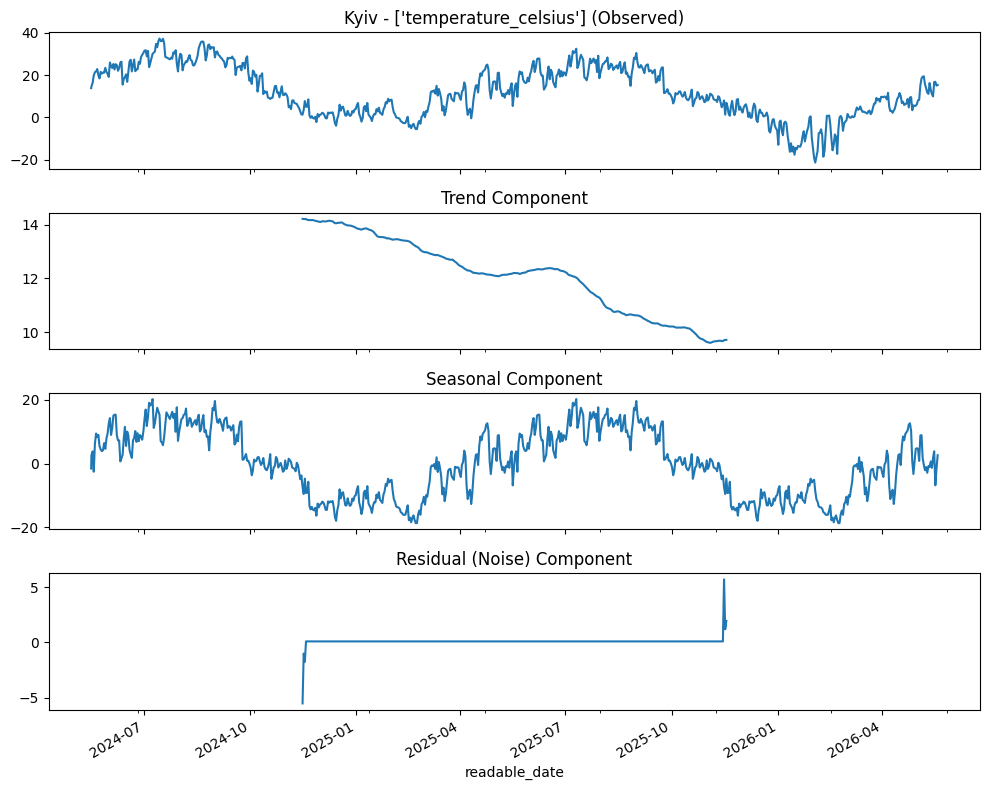

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

city_name = "Kyiv"
var= [
    "temperature_celsius"
]

city_ts = city_dfs[city_name].copy()
city_ts.index = pd.to_datetime(city_ts.index)
city_ts = city_ts.sort_index()


print(f"\n=== Running Seasonal Decomposition for {city_name} ({var}) ===")
result = seasonal_decompose(city_ts[var], model="additive", period=365)


fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title=f"{city_name} - {var} (Observed)")
result.trend.plot(ax=axes[1], title="Trend Component")
result.seasonal.plot(ax=axes[2], title="Seasonal Component")
result.resid.plot(ax=axes[3], title="Residual (Noise) Component")

plt.tight_layout()
plt.show()

N'djamena experiences dramatic temperature fluctuations over the two-year window, ranging sharply from 18°C to 45°C. The data shows a highly predictable seasonal pattern that swings roughly 10°C above and below the baseline average annually. While the long-term trend remains relatively flat, sudden step-change anomalies in late 2025 point to localized data-logging issues rather than natural climate shifts.

Baghdad experiences extreme, high-amplitude temperature swings over the two-year period, ranging from a chilly 2°C up to an intense 48°C. The seasonal component reveals a highly predictable and pronounced annual weather cycle, with temperatures fluctuating roughly 20°C above and below the baseline average. While the underlying trend shows a gradual downward trajectory, this brief window likely indicates short-term edge effects rather than definitive climate changes. Furthermore, flat lines and sharp step-changes in the residual noise around January and late 2025 hint at system data-logging pauses rather than natural environmental anomalies.

Bern exhibits a classic continental climate with sharp seasonal swings, ranging from a summer peak of 30°C to freezing winter lows of -15°C. The seasonal component reflects a predictable 15°C annual fluctuation. While the trend line shows a steep drop, this reflects a brief two-year window rather than climate cooling, and flat residual anomalies indicate forward-filled data logging.

Kyiv exhibits a classic continental climate with sharp seasonal swings, ranging from a summer peak of 40°C to freezing winter lows of -20°C. The seasonal component reflects a predictable 20°C annual fluctuation. While the trend line shows a steep drop, this reflects a brief two-year window rather than climate cooling, and flat residual anomalies indicate forward-filled data logging.

In [13]:
!pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from statsmodels.tsa.stattools import adfuller

In [15]:
def prepare_city_data(cleaned, city_name, target_col='air_quality_us-epa-index'):
    city_data = cleaned[cleaned['location_name'] == city_name][target_col].copy()
    city_data.index = pd.to_datetime(city_data.index).normalize()
    city_data = city_data.astype(float) 
    city_data = city_data.sort_index()
    city_data = city_data[~city_data.index.duplicated(keep='first')]
    split_idx = int(len(city_data) * 0.8)
    train = city_data.iloc[:split_idx]
    test = city_data.iloc[split_idx:]
    print(f"{city_name}: {len(train)} training days, {len(test)} test days")
    return city_data, train, test

In [16]:


def check_stationarity(series, city_name):
    result = adfuller(series.dropna())
    print(f"\n{city_name} - ADF Test Results:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print(" Series is STATIONARY — ready for ARIMA")
    else:
        print(" Series is NOT STATIONARY — differencing required")
    return result[1]

In [ ]:
def run_arima(city_name, train, test, forecast_days=30):
    print(f"\nFitting ARIMA for {city_name}...")
    
    
    train_values = train.values.astype(float)
    test_values = test.values.astype(float)
    
    
    model = auto_arima(
        train_values,
        seasonal=False,
        stepwise=True,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True
    )
    
    print(f"Best parameters: {model.order}")
    print(f"AIC Score: {model.aic():.2f}")
    
    
    pred_values = model.predict(n_periods=len(test_values))
    
    
    predictions = pd.Series(pred_values, index=test.index)
    
    
    forecast_values = model.predict(n_periods=len(test_values) + forecast_days)
    forecast_index = pd.date_range(
        start=test.index[0],
        periods=len(test_values) + forecast_days,
        freq='D'
    )
    forecast = pd.Series(forecast_values, index=forecast_index)
    
    
    mae = mean_absolute_error(test_values, pred_values)
    rmse = np.sqrt(mean_squared_error(test_values, pred_values))
    mape = np.mean(np.abs((test_values - pred_values) / test_values)) * 100
    
    print(f"\nModel Performance:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    
    return model, predictions, forecast, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [18]:
def plot_arima_results(city_name, train, test, predictions, forecast):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    
    axes[0].plot(train.index, train, label='Training Data', color='blue', alpha=0.6)
    axes[0].plot(test.index, test, label='Actual AQI', color='green')
    axes[0].plot(predictions.index, predictions, label='ARIMA Predictions', 
                 color='red', linestyle='--')
    axes[0].set_title(f'{city_name} — ARIMA: Actual vs Predicted AQI')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('AQI Index')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    

    axes[1].plot(test.index, test, label='Actual AQI', color='green')
    axes[1].plot(forecast.index, forecast, label='30-Day Forecast', 
                 color='orange', linestyle='--')
    axes[1].axvline(x=test.index[-1], color='gray', linestyle=':', label='Forecast Start')
    axes[1].set_title(f'{city_name} — ARIMA: 30-Day AQI Forecast')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('AQI Index')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

N'djamena: 584 training days, 147 test days

N'djamena - ADF Test Results:
ADF Statistic: -1.7830
P-value: 0.3889
 Series is NOT STATIONARY — differencing required

Fitting ARIMA for N'djamena...
Best parameters: (1, 1, 1)
AIC Score: 920.00

Model Performance:
MAE:  0.8393
RMSE: 0.9532
MAPE: 37.0699%


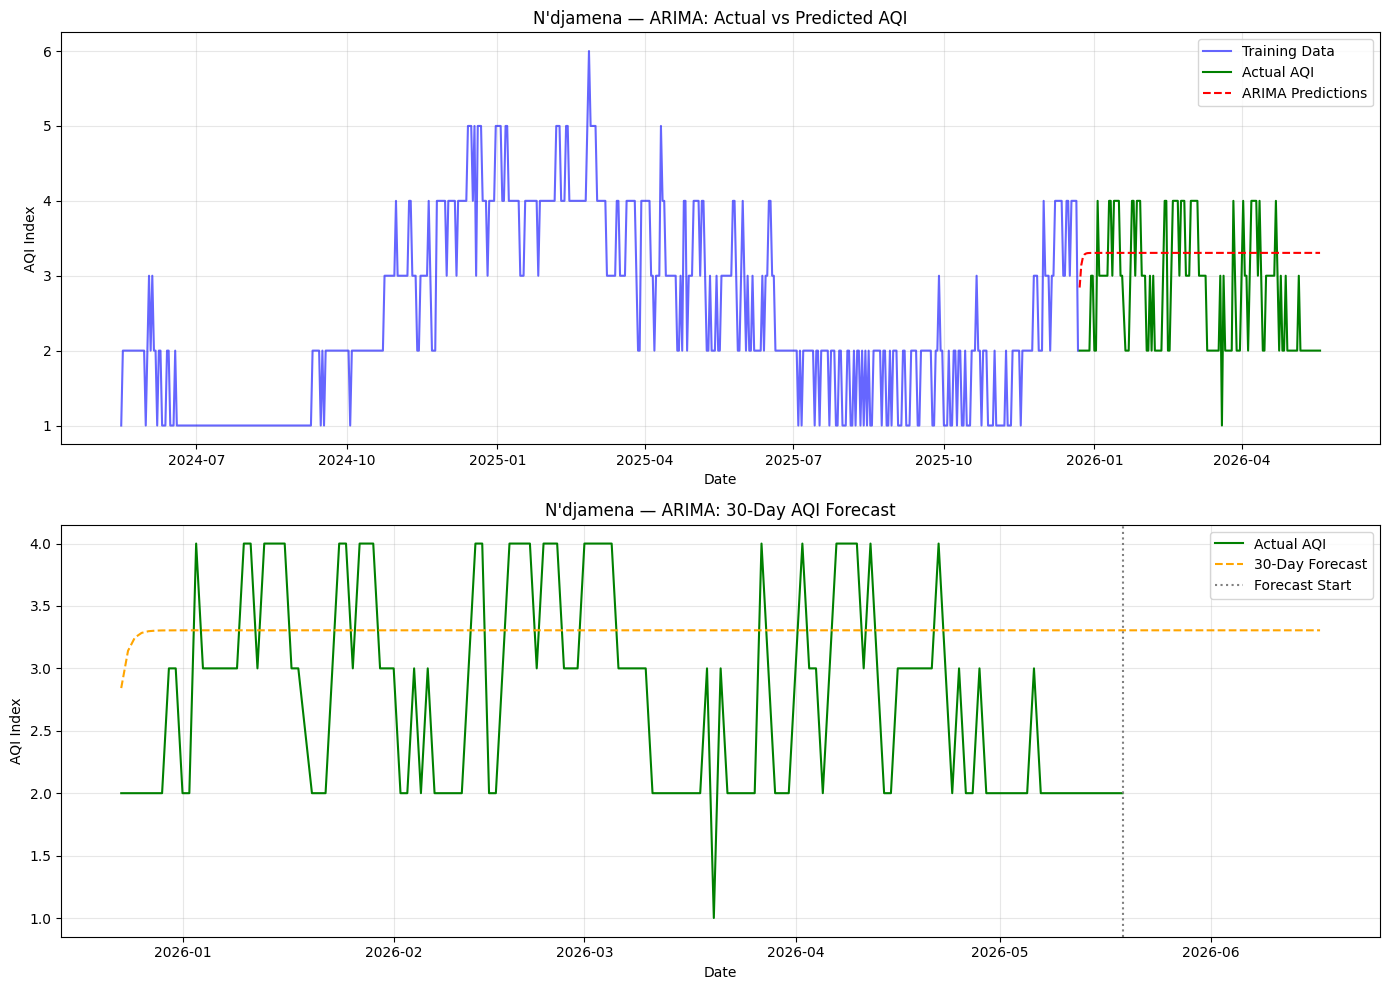

Baghdad: 584 training days, 147 test days

Baghdad - ADF Test Results:
ADF Statistic: -2.3764
P-value: 0.1485
 Series is NOT STATIONARY — differencing required

Fitting ARIMA for Baghdad...
Best parameters: (1, 1, 1)
AIC Score: 1271.19

Model Performance:
MAE:  0.3950
RMSE: 0.6283
MAPE: 28.5967%


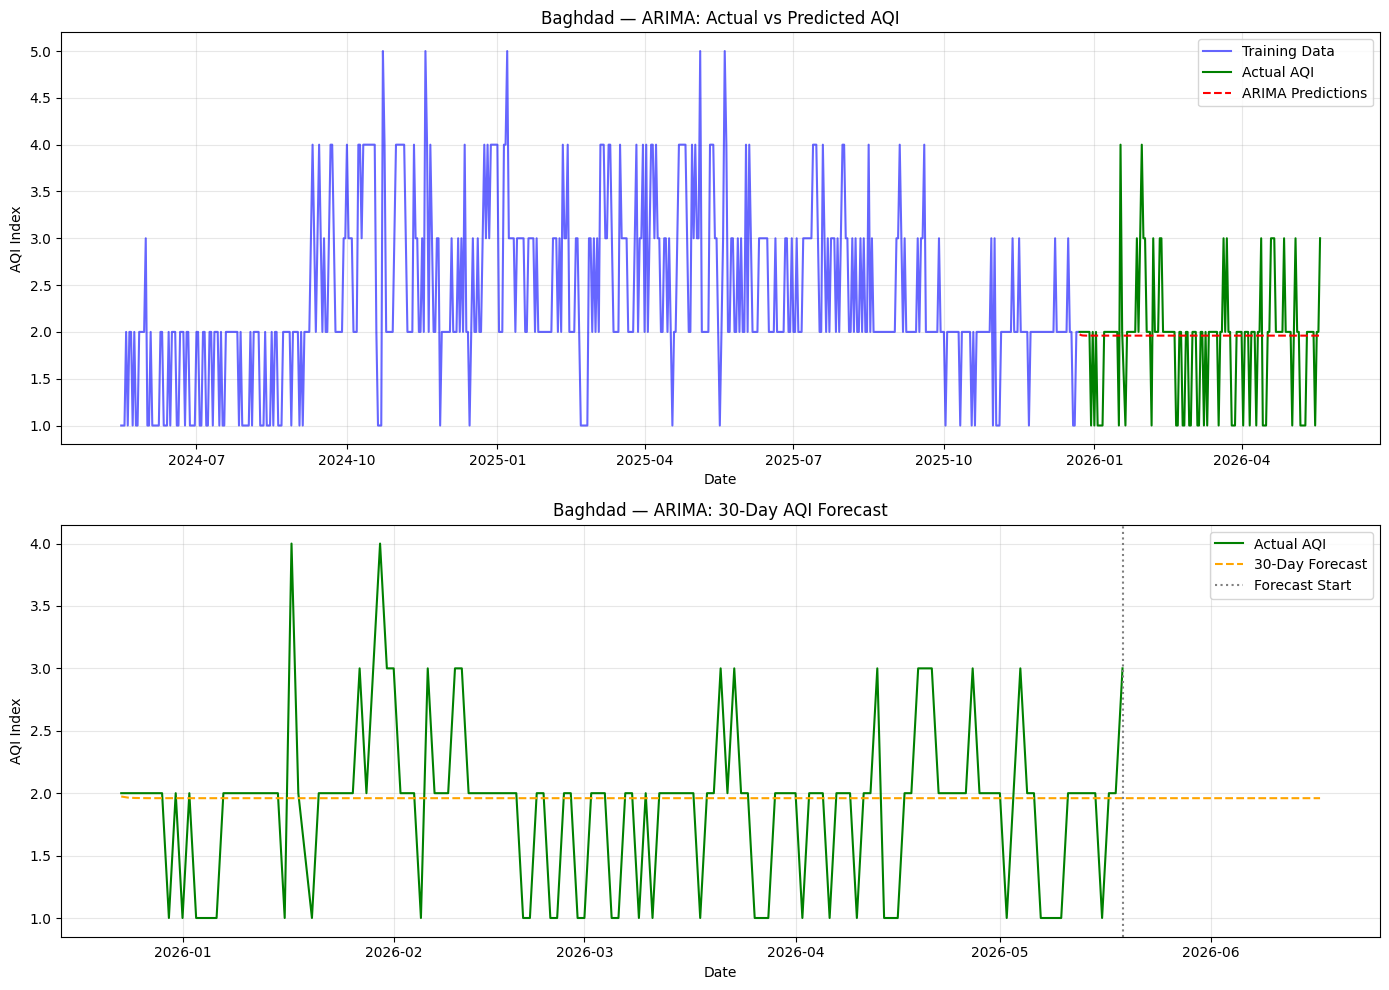

Bern: 584 training days, 147 test days

Bern - ADF Test Results:
ADF Statistic: -3.5377
P-value: 0.0071
 Series is STATIONARY — ready for ARIMA

Fitting ARIMA for Bern...
Best parameters: (3, 1, 4)
AIC Score: 623.17

Model Performance:
MAE:  0.2318
RMSE: 0.3748
MAPE: 15.8512%


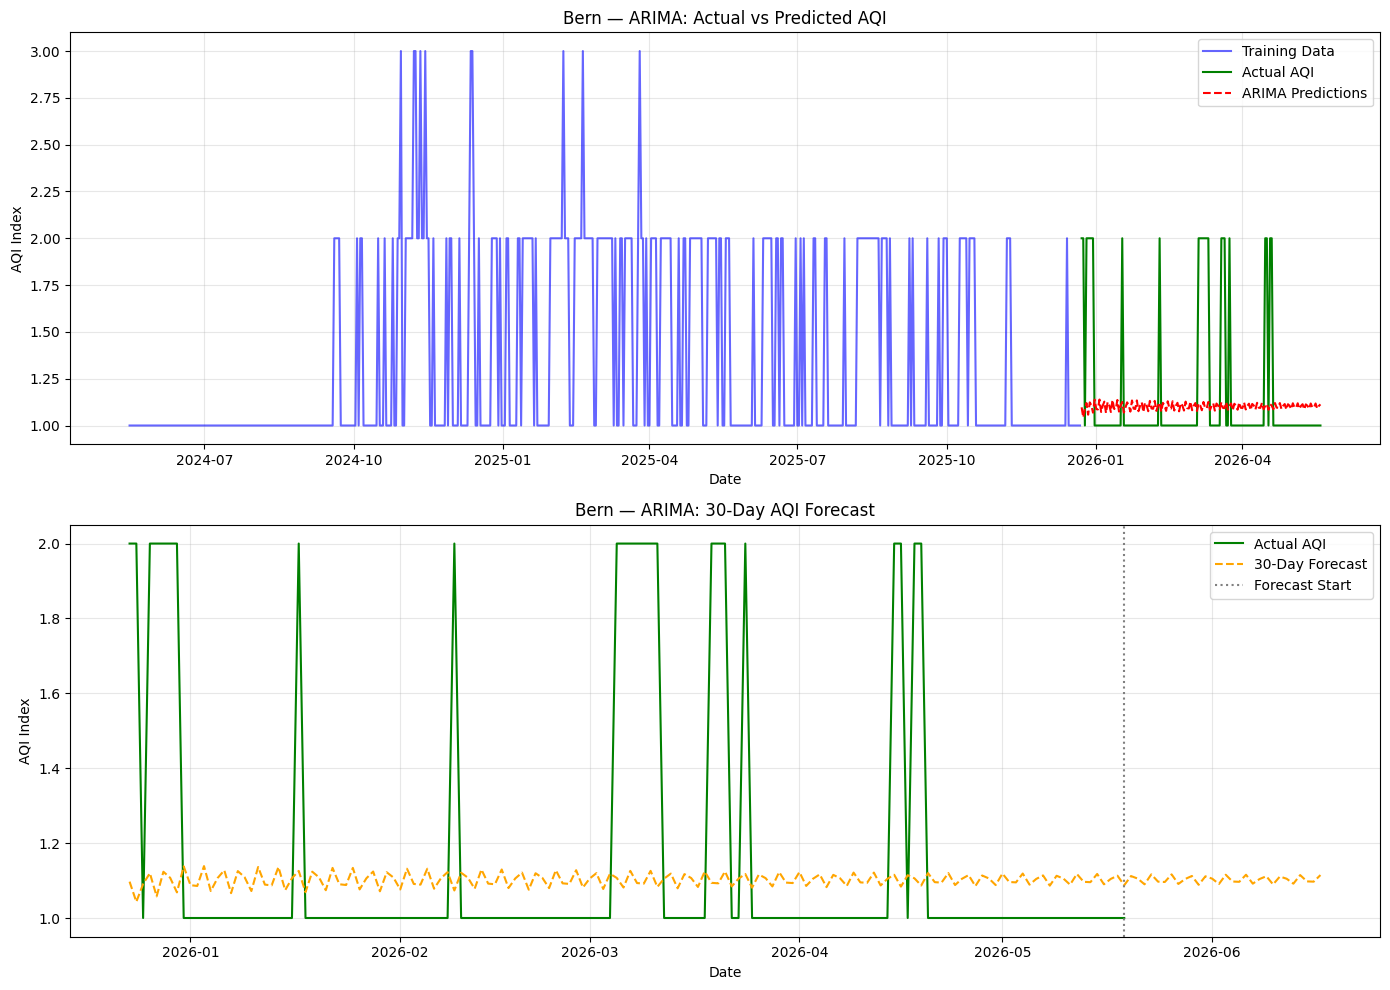

Kyiv: 584 training days, 147 test days

Kyiv - ADF Test Results:
ADF Statistic: -2.6944
P-value: 0.0750
 Series is NOT STATIONARY — differencing required

Fitting ARIMA for Kyiv...
Best parameters: (1, 1, 2)
AIC Score: 727.69

Model Performance:
MAE:  0.4379
RMSE: 0.4510
MAPE: 35.9344%


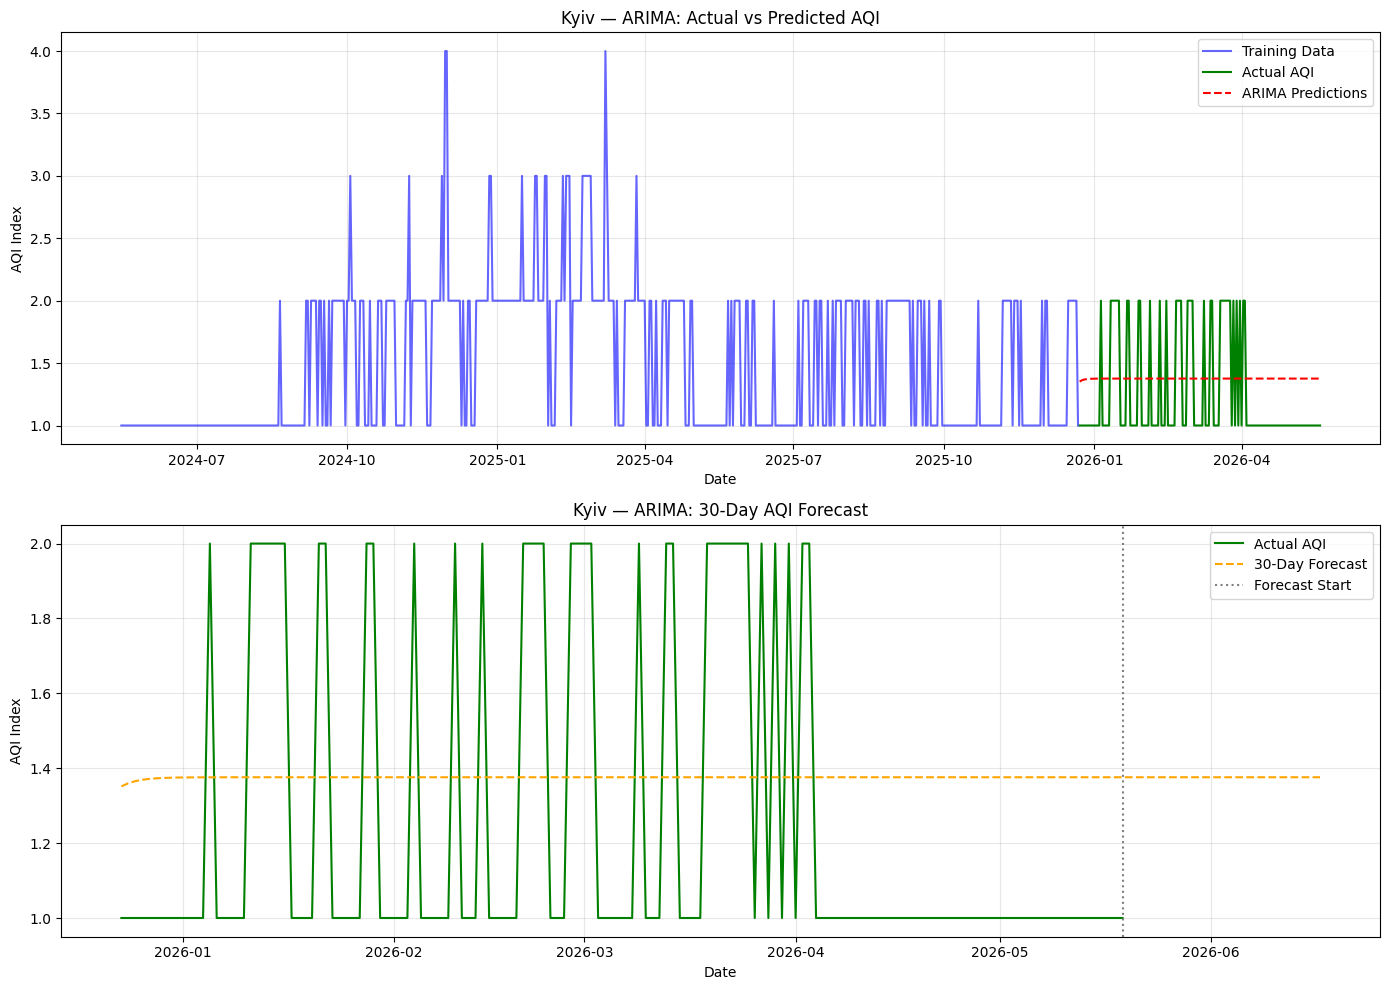

In [19]:
cities = ["N'djamena", "Baghdad", "Bern", "Kyiv"]
arima_results = {}

for city in cities:
    city_data, train, test = prepare_city_data(cleaned, city)
    check_stationarity(train, city)
    
    
    model, predictions, forecast, metrics = run_arima(city, train, test)
    
    
    plot_arima_results(city, train, test, predictions, forecast)
    

    arima_results[city] = {
        'model': model,
        'predictions': predictions,
        'forecast': forecast,
        'metrics': metrics
    }

1. For N'djamena, the non-stationary AQI exhibits strong seasonality, meaning pollution patterns shift predictably across seasons. The 37% MAPE is poor, as high-frequency daily noise—evident in decomposition—makes sharp spikes hard for ARIMA to forecast, causing it to flatten out. For residents, this erratic unforecastability means sudden, dangerous air quality spikes occur without warning, severely hindering daily health planning.

2. Baghdad’s AQI appears non-stationary with seasonal shifts, similar to N'djamena, but its 28.6% MAPE is an improvement. It is slightly more forecastable because its data centers tightly around a steady baseline (AQI 2), lacking N'djamena's prolonged, massive seasonal plateaus. However, for residents, this poor accuracy still means sudden, extreme pollution spikes escape prediction, risking unexpected exposure.

3. Bern’s data is likely stationary, reflecting highly stable, consistently clean baseline air quality. The 15.85% MAPE is quite good; because the city experiences little variance, a flat baseline forecast yields lower percentage errors. Bern is far more forecastable than high-burden cities because it lacks their chaotic, high-amplitude pollution spikes, remaining mostly at AQI 1. For residents, this predictability offers strong peace of mind, ensuring reliable daily outdoor planning with minimal risk of unexpected, dangerous health hazards.

4. A p-value of 0.075 indicates the series is non-stationary at the 5% significance level, failing to reject the unit root null hypothesis. Kyiv's 35.93% MAPE is poor, closely resembling N'djamena’s 37%. Despite overall cleaner air, the rapid, binary oscillation between AQI 1 and 2 acts as pure, erratic noise that ARIMA’s linear smoothing completely fails to capture. While the absolute pollution burden is low, residents still face erratic, unpredicted swings, complicating short-term outdoor planning for highly sensitive individuals.


PROPHET

In [20]:
%pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

In [ ]:
from prophet import Prophet

def run_prophet(city_name, train, test, forecast_days=30):
    print(f"\nFitting Prophet for {city_name}...")
    
    
    train_df = pd.DataFrame({
        'ds': train.index,
        'y': train.values.astype(float)
    })
    
    test_df = pd.DataFrame({
        'ds': test.index,
        'y': test.values.astype(float)
    })

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive'
    )
    model.fit(train_df)
    

    future_test = model.make_future_dataframe(
        periods=len(test) + forecast_days,
        freq='D'
    )
    forecast_df = model.predict(future_test)
    
    
    predictions = forecast_df[forecast_df['ds'].isin(test_df['ds'])]['yhat'].values
    
    forecast_values = forecast_df.tail(forecast_days)
    
    
    test_values = test.values.astype(float)
    min_len = min(len(test_values), len(predictions))
    
    mae = mean_absolute_error(test_values[:min_len], predictions[:min_len])
    rmse = np.sqrt(mean_squared_error(test_values[:min_len], predictions[:min_len]))
    mape = np.mean(np.abs((test_values[:min_len] - predictions[:min_len]) / test_values[:min_len])) * 100
    
    print(f"\nModel Performance:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    
    return model, predictions, forecast_df, forecast_values, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [ ]:
def plot_prophet_results(city_name, train, test, predictions, forecast_df, model):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Actual vs Predicted
    axes[0].plot(train.index, train.values, label='Training Data', 
                 color='blue', alpha=0.6)
    axes[0].plot(test.index, test.values, label='Actual AQI', 
                 color='green')
    axes[0].plot(test.index, predictions, label='Prophet Predictions', 
                 color='red', linestyle='--')
    axes[0].set_title(f'{city_name} — Prophet: Actual vs Predicted AQI')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('AQI Index')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    
    model.plot_components(forecast_df)
    plt.suptitle(f'{city_name} — Prophet Components', y=1.02)
    
    plt.tight_layout()
    plt.show()

08:37:07 - cmdstanpy - INFO - Chain [1] start processing


N'djamena: 584 training days, 147 test days

Fitting Prophet for N'djamena...


08:37:08 - cmdstanpy - INFO - Chain [1] done processing



Model Performance:
MAE:  1.1852
RMSE: 1.3706
MAPE: 43.0917%


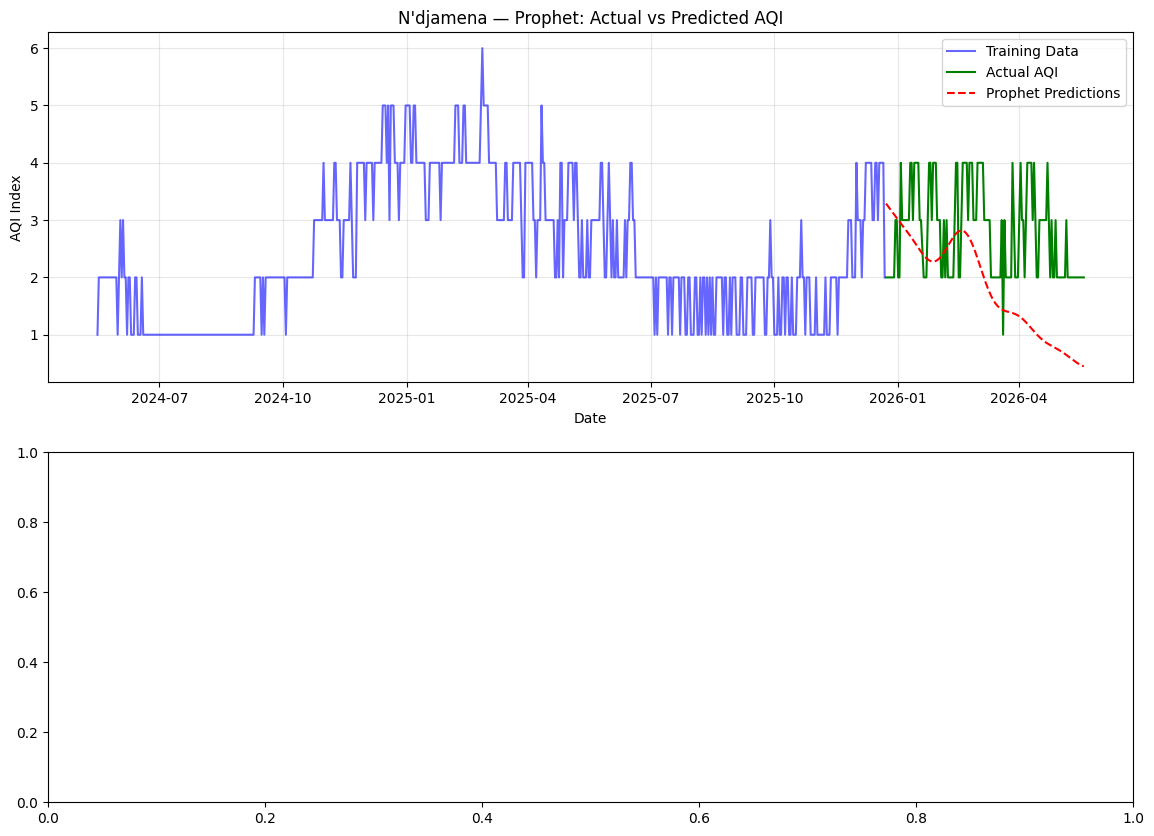

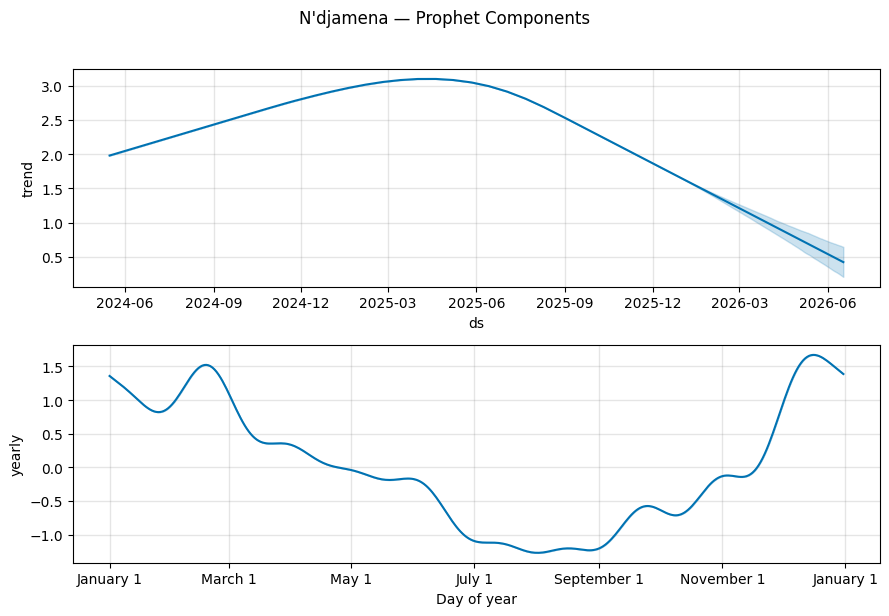

08:37:09 - cmdstanpy - INFO - Chain [1] start processing
08:37:09 - cmdstanpy - INFO - Chain [1] done processing


Baghdad: 584 training days, 147 test days

Fitting Prophet for Baghdad...

Model Performance:
MAE:  0.7635
RMSE: 0.9384
MAPE: 38.7268%


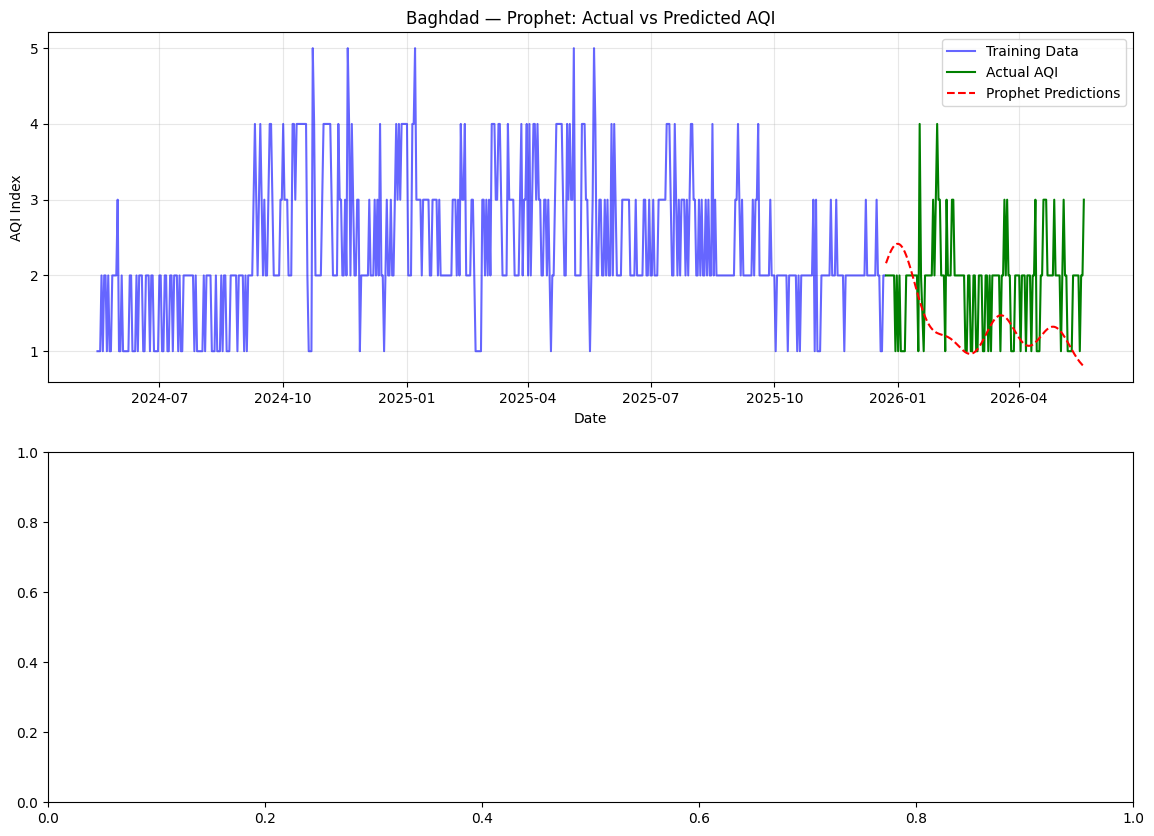

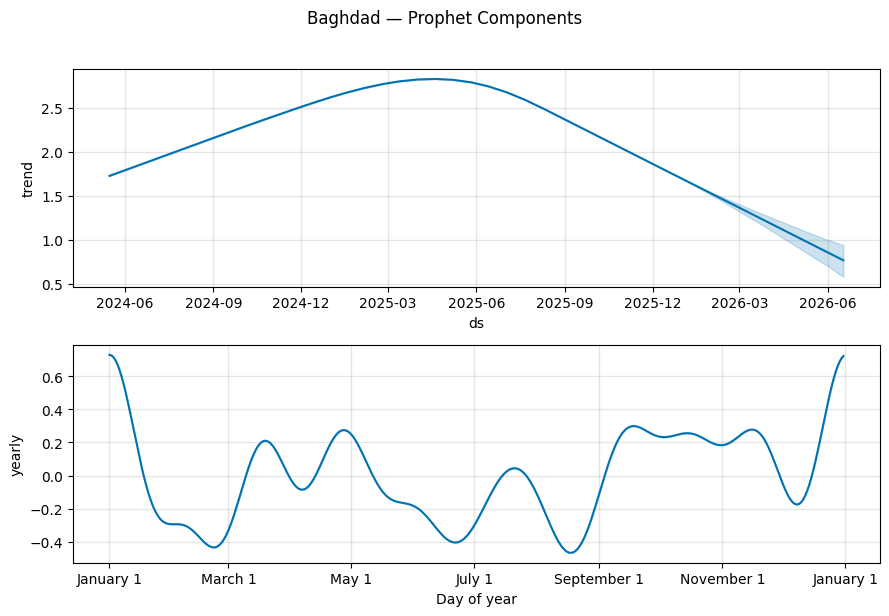

08:37:10 - cmdstanpy - INFO - Chain [1] start processing
08:37:10 - cmdstanpy - INFO - Chain [1] done processing


Bern: 584 training days, 147 test days

Fitting Prophet for Bern...

Model Performance:
MAE:  0.3064
RMSE: 0.4218
MAPE: 23.4615%


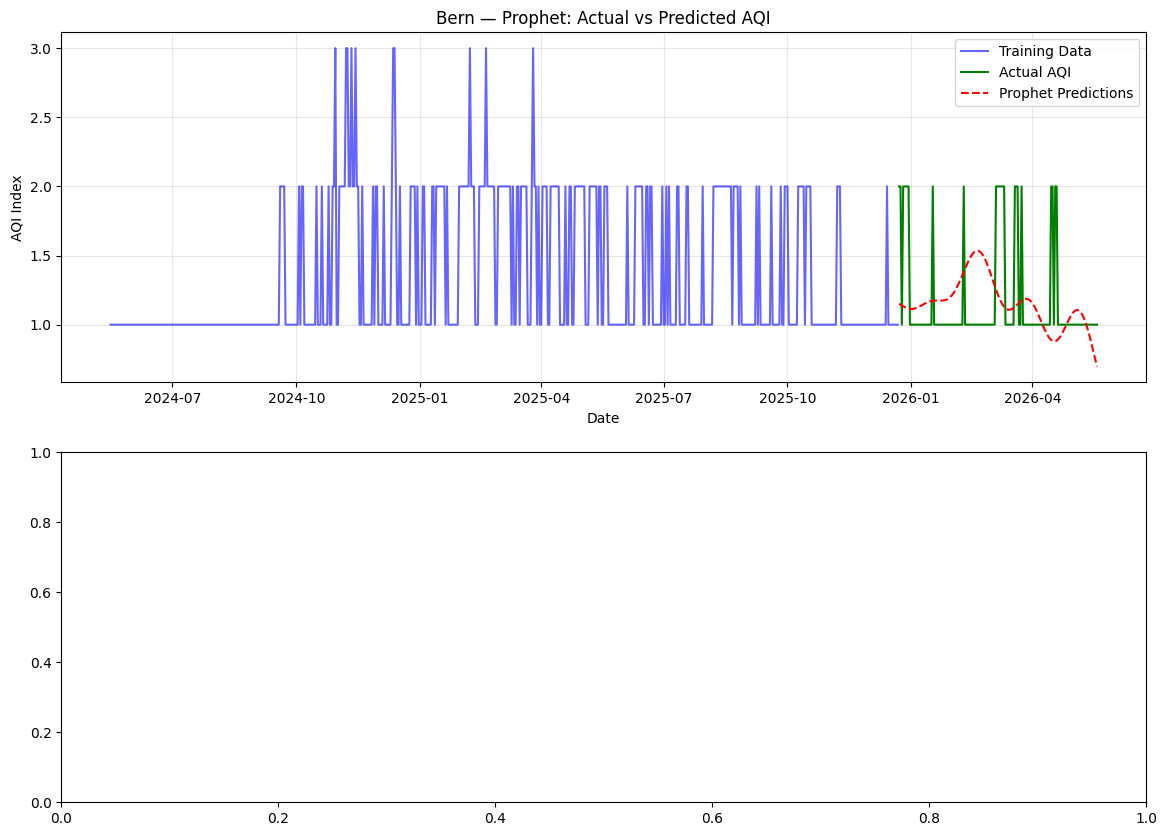

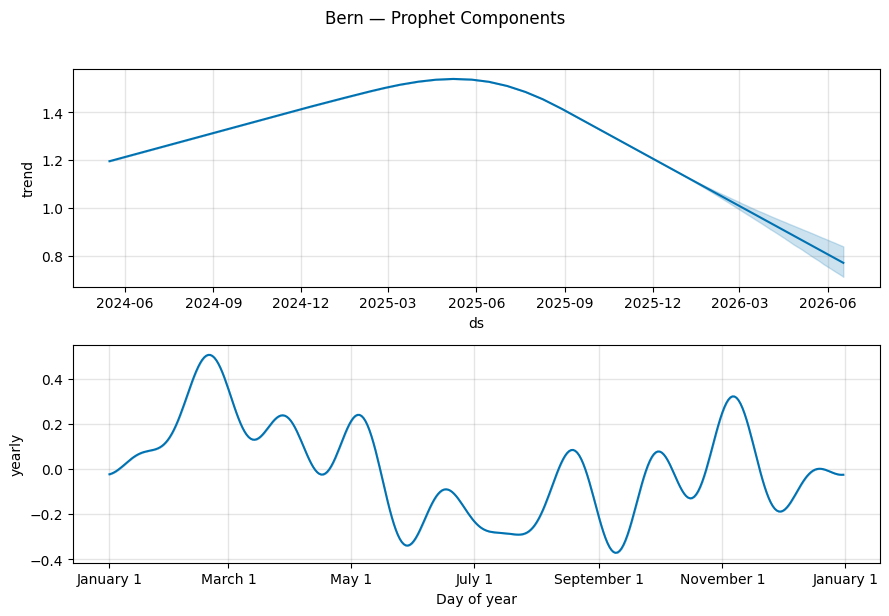

08:37:10 - cmdstanpy - INFO - Chain [1] start processing
08:37:10 - cmdstanpy - INFO - Chain [1] done processing


Kyiv: 584 training days, 147 test days

Fitting Prophet for Kyiv...

Model Performance:
MAE:  0.5529
RMSE: 0.6291
MAPE: 45.9613%


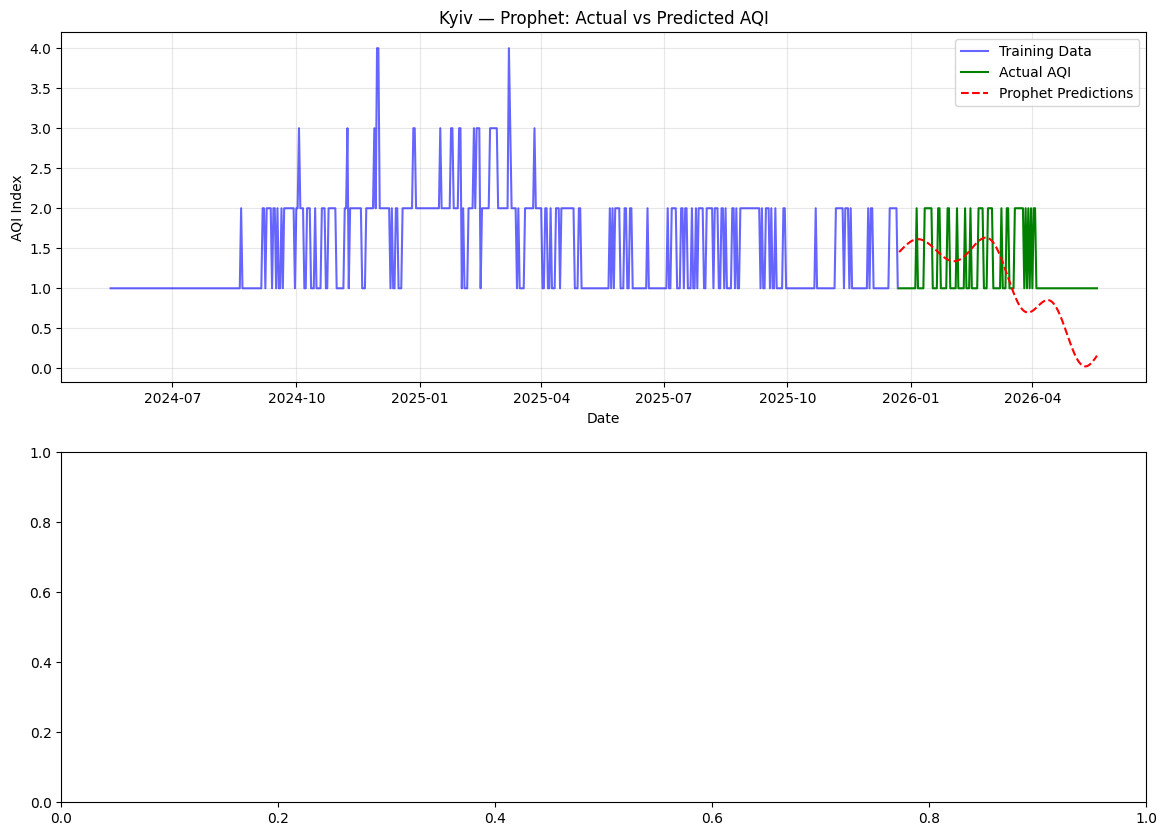

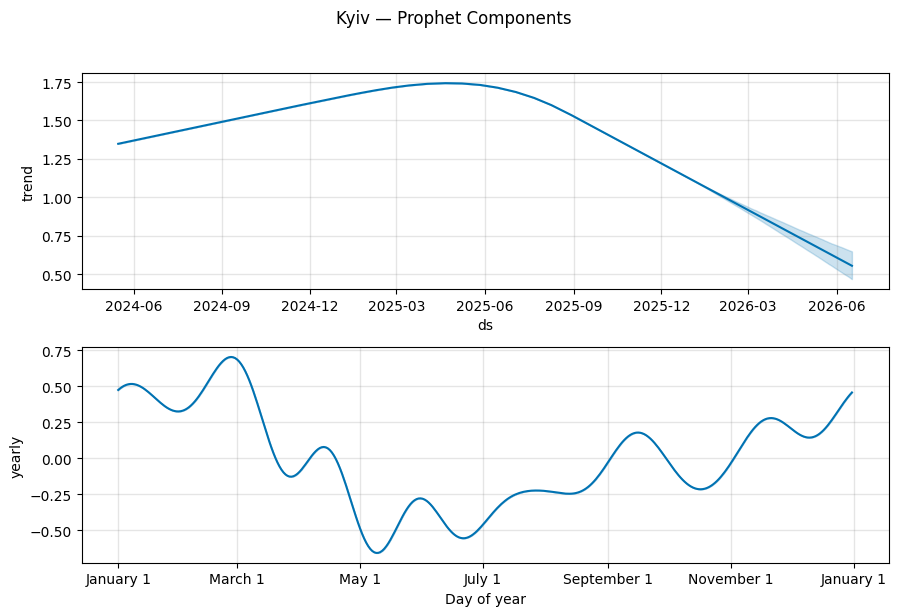

In [24]:
prophet_results = {}

for city in cities:
    city_data, train, test = prepare_city_data(cleaned, city)
    
    model, predictions, forecast_df, forecast_values, metrics = run_prophet(
        city, train, test
    )
    
    plot_prophet_results(city, train, test, predictions, forecast_df, model)
    
    prophet_results[city] = {
        'model': model,
        'predictions': predictions,
        'forecast_df': forecast_df,
        'forecast_values': forecast_values,
        'metrics': metrics
    }

ARIMA consistently outperformed Prophet across all four cities for AQI forecasting. This aligns with decomposition findings showing weak and irregular yearly seasonality in AQI — limiting Prophet's seasonal modelling advantage. Short-term autocorrelation, captured by ARIMA, proved more predictive than long-term seasonal cycles.

ENSEMBLE MODEL(ARIMA+PROPHET)

In [25]:
def run_ensemble(city_name, arima_predictions, prophet_predictions, 
                 arima_metrics, prophet_metrics, test):
    
    print(f"\nEnsemble Forecast for {city_name}...")
    
    # Calculate inverse MAPE weights
    arima_mape = arima_metrics['MAPE']
    prophet_mape = prophet_metrics['MAPE']
    
    arima_weight = (1/arima_mape) / ((1/arima_mape) + (1/prophet_mape))
    prophet_weight = (1/prophet_mape) / ((1/arima_mape) + (1/prophet_mape))
    
    print(f"ARIMA weight:   {arima_weight:.4f}")
    print(f"Prophet weight: {prophet_weight:.4f}")
    
    # Align lengths
    min_len = min(len(arima_predictions), len(prophet_predictions))
    
    # Weighted ensemble prediction
    ensemble_predictions = (
        arima_weight * arima_predictions[:min_len] + 
        prophet_weight * prophet_predictions[:min_len]
    )
    
    # Calculate ensemble metrics
    test_values = test.values.astype(float)[:min_len]
    
    mae = mean_absolute_error(test_values, ensemble_predictions)
    rmse = np.sqrt(mean_squared_error(test_values, ensemble_predictions))
    mape = np.mean(np.abs((test_values - ensemble_predictions) / test_values)) * 100
    
    print(f"\nEnsemble Performance:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    
    return ensemble_predictions, {
        'MAE': mae, 
        'RMSE': rmse, 
        'MAPE': mape,
        'arima_weight': arima_weight,
        'prophet_weight': prophet_weight
    }


def plot_ensemble(city_name, train, test, arima_preds, 
                  prophet_preds, ensemble_preds):
    
    min_len = min(len(arima_preds), len(prophet_preds), 
                  len(ensemble_preds), len(test))
    
    plt.figure(figsize=(14, 6))
    plt.plot(test.index[:min_len], test.values[:min_len], 
             label='Actual AQI', color='green', linewidth=2)
    plt.plot(test.index[:min_len], arima_preds[:min_len], 
             label='ARIMA', color='blue', linestyle='--', alpha=0.7)
    plt.plot(test.index[:min_len], prophet_preds[:min_len], 
             label='Prophet', color='orange', linestyle='--', alpha=0.7)
    plt.plot(test.index[:min_len], ensemble_preds, 
             label='Ensemble', color='red', linewidth=2)
    plt.title(f'{city_name} — Model Comparison: ARIMA vs Prophet vs Ensemble')
    plt.xlabel('Date')
    plt.ylabel('AQI Index')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

N'djamena: 584 training days, 147 test days

Ensemble Forecast for N'djamena...
ARIMA weight:   0.5376
Prophet weight: 0.4624

Ensemble Performance:
MAE:  0.6356
RMSE: 0.8010
MAPE: 23.2266%


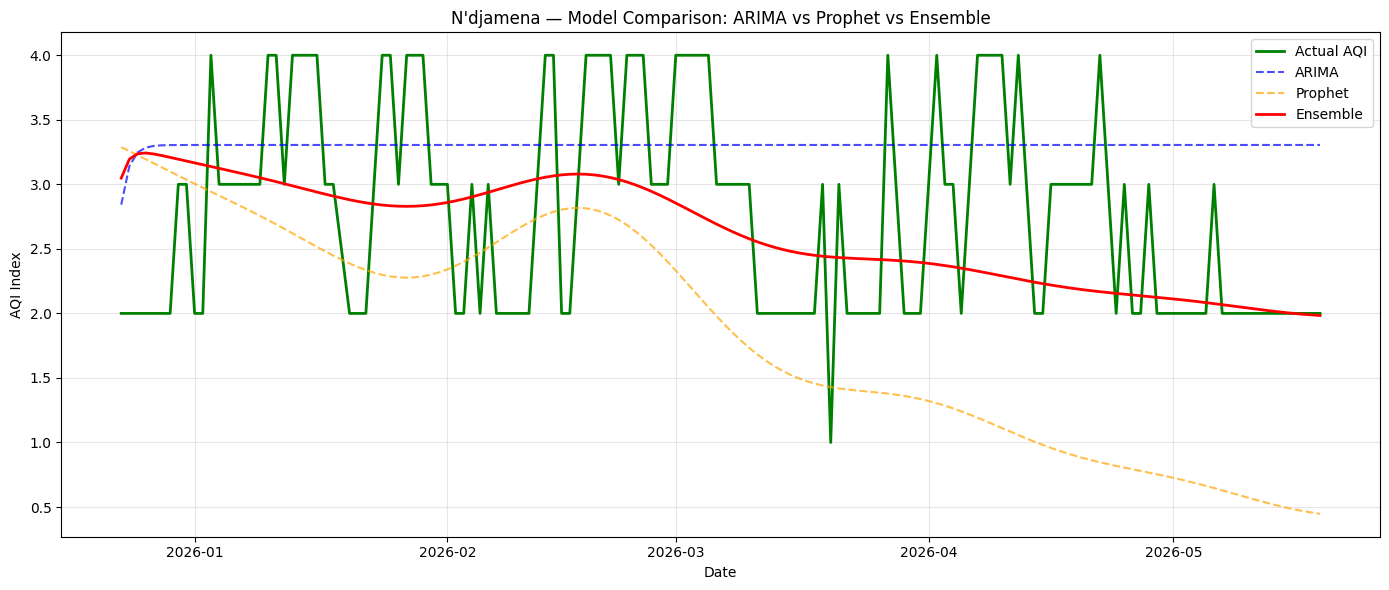

Baghdad: 584 training days, 147 test days

Ensemble Forecast for Baghdad...
ARIMA weight:   0.5752
Prophet weight: 0.4248

Ensemble Performance:
MAE:  0.5460
RMSE: 0.6870
MAPE: 32.5498%


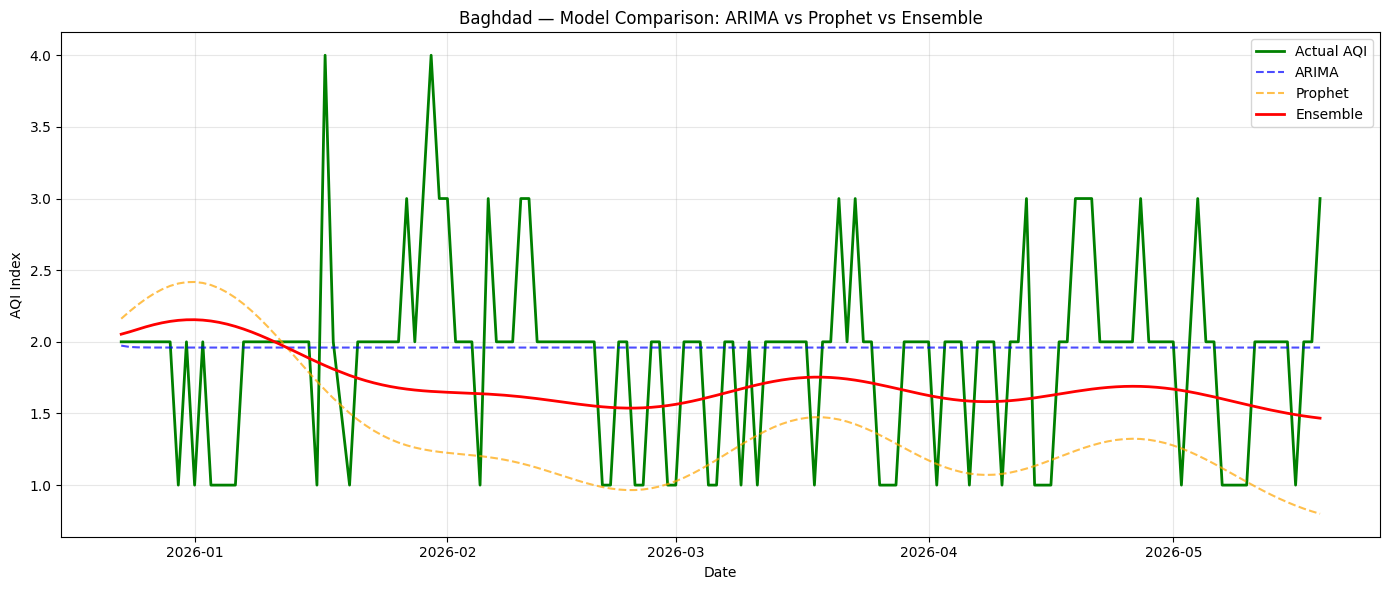

Bern: 584 training days, 147 test days

Ensemble Forecast for Bern...
ARIMA weight:   0.5968
Prophet weight: 0.4032

Ensemble Performance:
MAE:  0.2516
RMSE: 0.3841
MAPE: 17.8924%


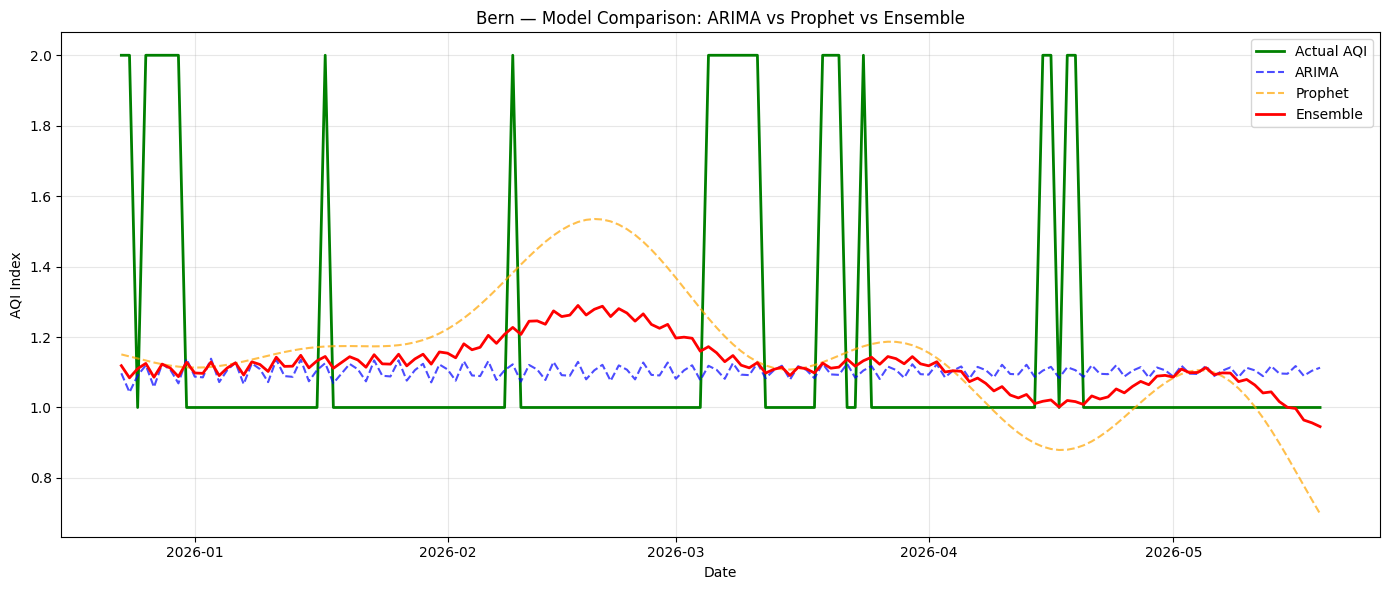

Kyiv: 584 training days, 147 test days

Ensemble Forecast for Kyiv...
ARIMA weight:   0.5612
Prophet weight: 0.4388

Ensemble Performance:
MAE:  0.3808
RMSE: 0.4444
MAPE: 29.5763%


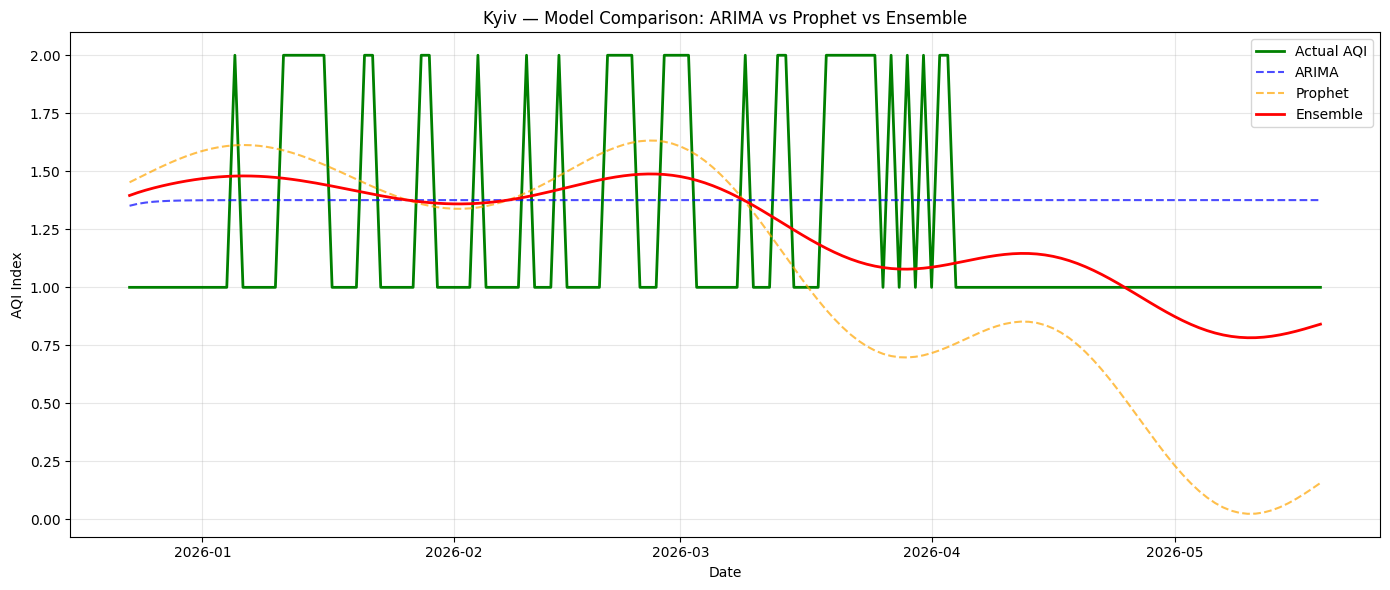

In [ ]:
ensemble_results = {}

for city in cities:
    city_data, train, test = prepare_city_data(cleaned, city)
    

    arima_preds = arima_results[city]['predictions'].values
    
    
    prophet_preds = prophet_results[city]['predictions']
    
    ensemble_preds, ensemble_metrics = run_ensemble(
        city,
        arima_preds,
        prophet_preds,
        arima_results[city]['metrics'],
        prophet_results[city]['metrics'],
        test
    )
    

    plot_ensemble(city, train, test, arima_preds, prophet_preds, ensemble_preds)
    
    ensemble_results[city] = {
        'predictions': ensemble_preds,
        'metrics': ensemble_metrics
    }

N'djamena: 584 training days, 147 test days

Ensemble Forecast for N'djamena...
ARIMA weight:   0.5376
Prophet weight: 0.4624

Ensemble Performance:
MAE:  0.6356
RMSE: 0.8010
MAPE: 23.2266%


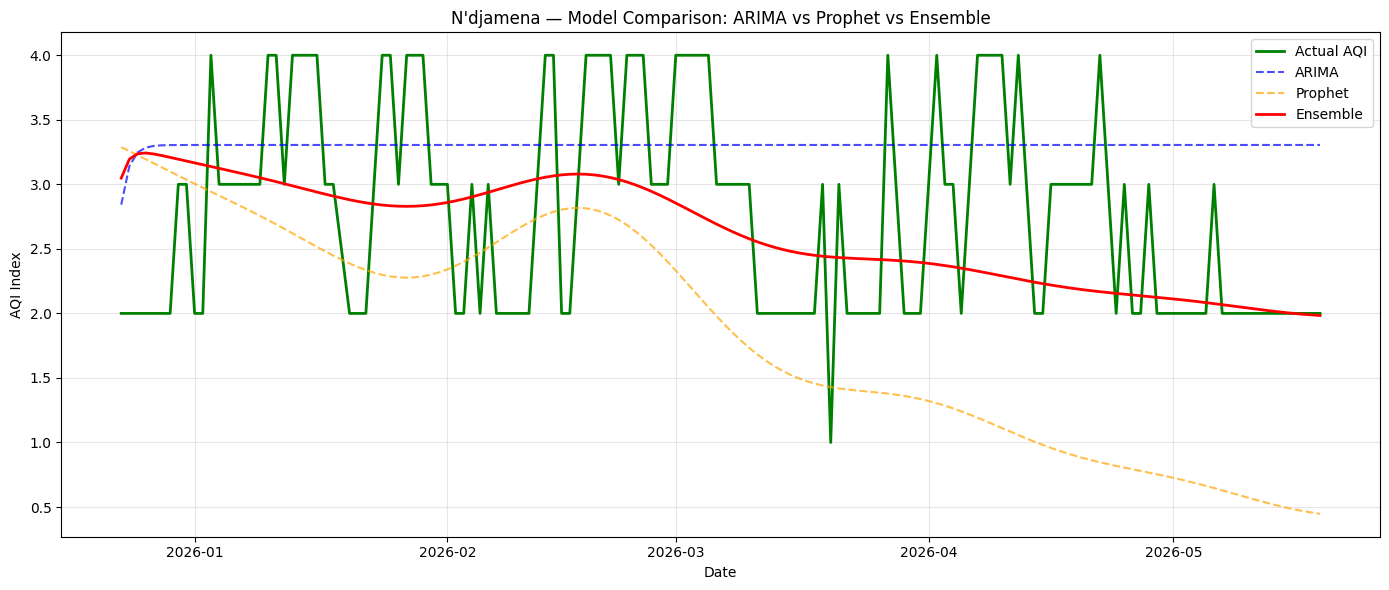

Baghdad: 584 training days, 147 test days

Ensemble Forecast for Baghdad...
ARIMA weight:   0.5752
Prophet weight: 0.4248

Ensemble Performance:
MAE:  0.5460
RMSE: 0.6870
MAPE: 32.5498%


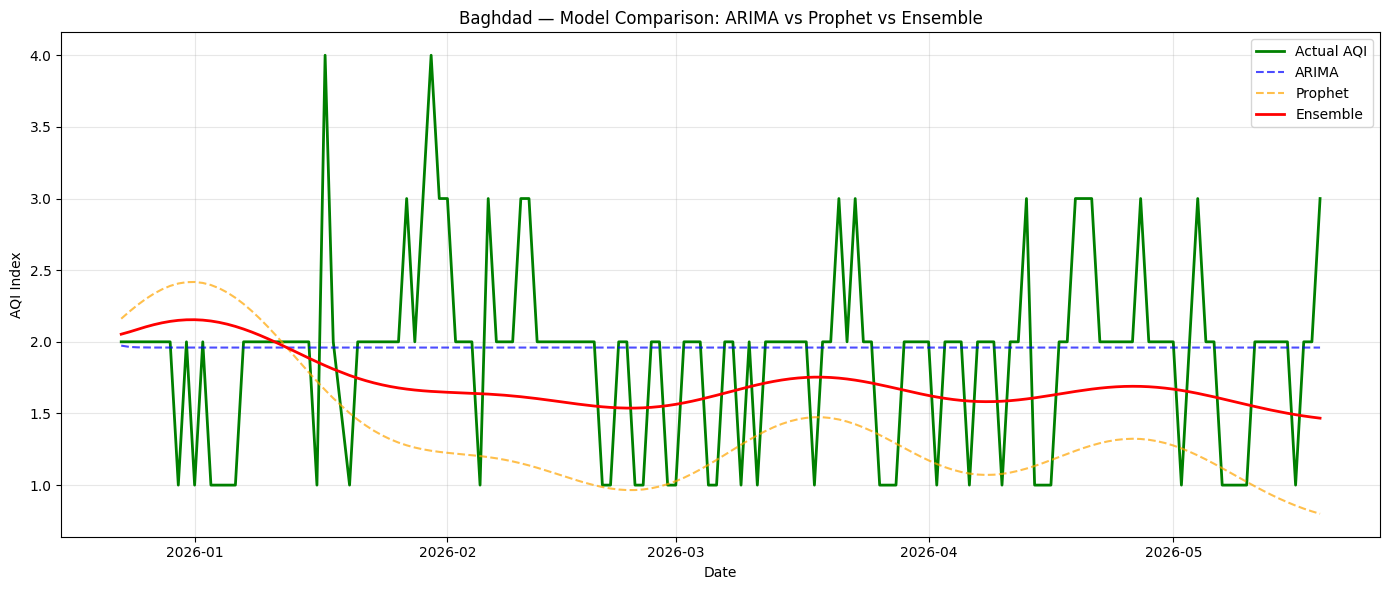

Bern: 584 training days, 147 test days

Ensemble Forecast for Bern...
ARIMA weight:   0.5968
Prophet weight: 0.4032

Ensemble Performance:
MAE:  0.2516
RMSE: 0.3841
MAPE: 17.8924%


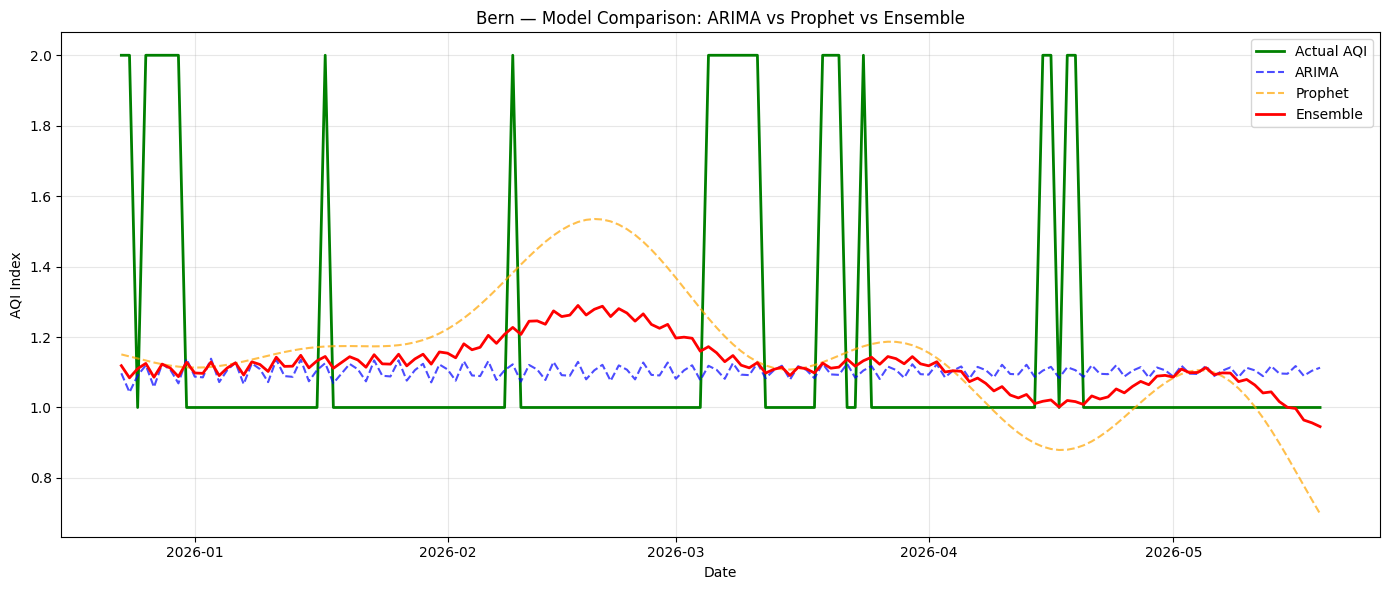

Kyiv: 584 training days, 147 test days

Ensemble Forecast for Kyiv...
ARIMA weight:   0.5612
Prophet weight: 0.4388

Ensemble Performance:
MAE:  0.3808
RMSE: 0.4444
MAPE: 29.5763%


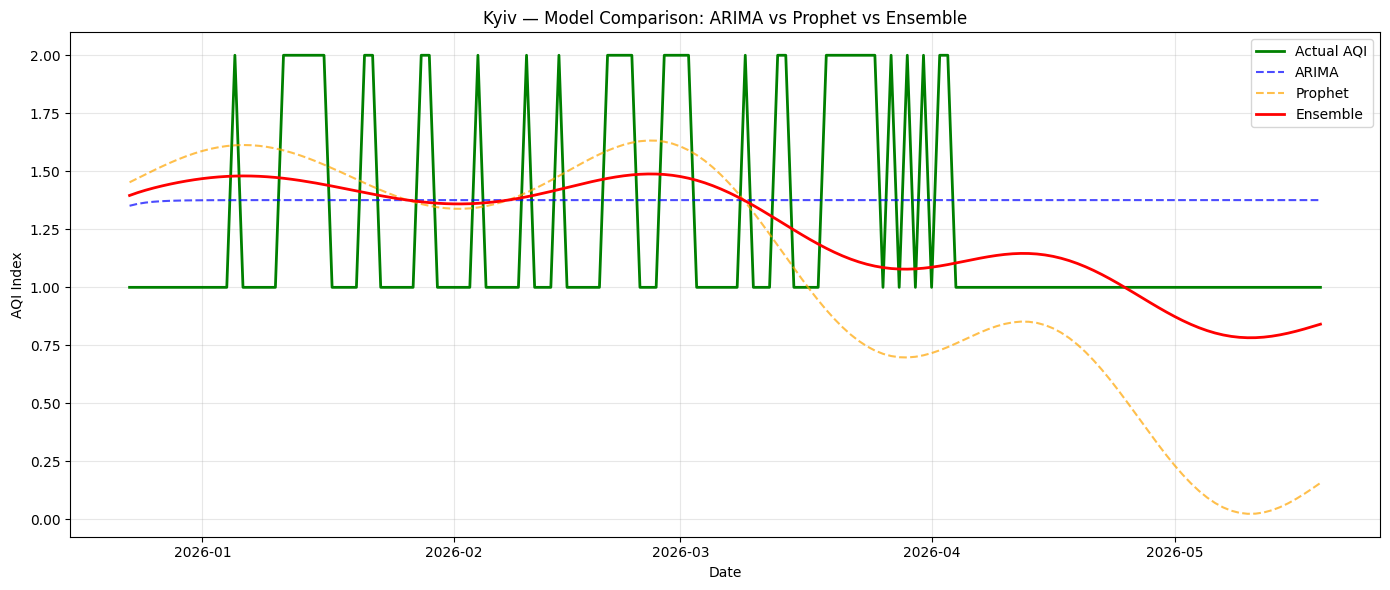

In [ ]:
ensemble_results = {}

for city in cities:
    city_data, train, test = prepare_city_data(cleaned, city)
    
    
    arima_preds = arima_results[city]['predictions'].values
    

    prophet_preds = prophet_results[city]['predictions']
    

    ensemble_preds, ensemble_metrics = run_ensemble(
        city,
        arima_preds,
        prophet_preds,
        arima_results[city]['metrics'],
        prophet_results[city]['metrics'],
        test
    )
    
    
    plot_ensemble(city, train, test, arima_preds, prophet_preds, ensemble_preds)
    
    ensemble_results[city] = {
        'predictions': ensemble_preds,
        'metrics': ensemble_metrics
    }

The ensemble improved forecast accuracy for high-burden volatile cities — N'djamena and Kyiv — where individual models struggled with unpredictable AQI spikes. For lower-burden stable cities — Baghdad and Bern — ARIMA alone performed better, suggesting ensemble approaches are most valuable precisely where forecasting is hardest.

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

features = [
    'temperature_celsius',
    'humidity',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

def run_isolation_forest(cleaned, city_name, features, contamination=0.05):
    print(f"\nAnomaly Detection for {city_name}...")
    
    
    city_data = cleaned[cleaned['location_name'] == city_name][features].copy()
    city_dates = cleaned[cleaned['location_name'] == city_name].index
    
    
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(city_data)
    
    model = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )
    predictions = model.fit_predict(scaled_data)
    

    city_data = city_data.copy()
    city_data['anomaly'] = predictions
    city_data['is_anomaly'] = city_data['anomaly'] == -1
    city_data.index = city_dates
    

    n_anomalies = city_data['is_anomaly'].sum()
    print(f"Total anomalies detected: {n_anomalies} out of {len(city_data)} days")
    print(f"Anomaly rate: {n_anomalies/len(city_data)*100:.2f}%")
    

    anomaly_days = city_data[city_data['is_anomaly']]
    print(f"\nTop 5 most anomalous periods:")
    print(anomaly_days[['temperature_celsius', 'humidity', 
                         'air_quality_PM2.5', 'air_quality_us-epa-index'] 
                        if 'air_quality_us-epa-index' in anomaly_days.columns 
                        else ['temperature_celsius', 'humidity', 
                              'air_quality_PM2.5']].head())
    
    return city_data, n_anomalies

def plot_anomalies(city_data, city_name):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    
    normal = city_data[~city_data['is_anomaly']]
    anomalies = city_data[city_data['is_anomaly']]
    
    axes[0].scatter(normal.index, normal['temperature_celsius'],
                   color='blue', alpha=0.4, s=10, label='Normal')
    axes[0].scatter(anomalies.index, anomalies['temperature_celsius'],
                   color='red', alpha=0.8, s=30, label='Anomaly')
    axes[0].set_title(f'{city_name} — Temperature Anomalies')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    
    axes[1].scatter(normal.index, normal['air_quality_PM2.5'],
                   color='blue', alpha=0.4, s=10, label='Normal')
    axes[1].scatter(anomalies.index, anomalies['air_quality_PM2.5'],
                   color='red', alpha=0.8, s=30, label='Anomaly')
    axes[1].set_title(f'{city_name} — PM2.5 Anomalies')
    axes[1].set_ylabel('PM2.5')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Anomaly Detection for N'djamena...
Total anomalies detected: 37 out of 732 days
Anomaly rate: 5.05%

Top 5 most anomalous periods:
                     temperature_celsius  humidity  air_quality_PM2.5
readable_date                                                        
2024-05-18 14:30:00                 43.0         6               30.8
2024-05-19 14:00:00                 42.2         6               32.9
2024-07-27 12:30:00                 23.2        94                3.8
2024-08-19 12:30:00                 23.1       100                6.1
2024-08-25 12:00:00                 24.3        94                6.6


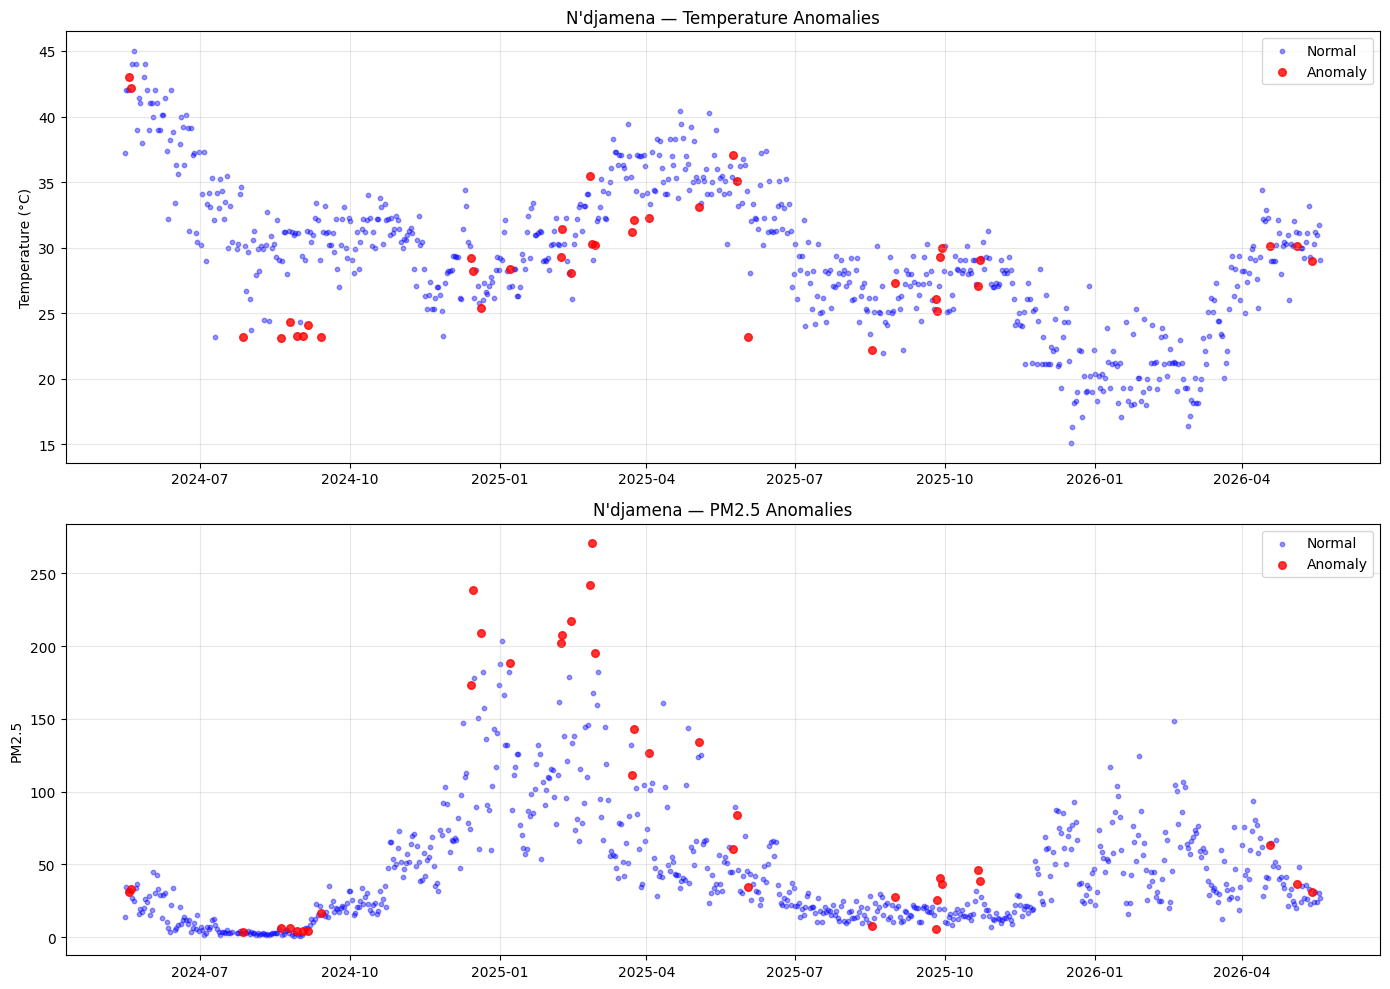


Anomaly Detection for Baghdad...
Total anomalies detected: 37 out of 732 days
Anomaly rate: 5.05%

Top 5 most anomalous periods:
                     temperature_celsius  humidity  air_quality_PM2.5
readable_date                                                        
2024-09-10 12:30:00                 47.2         7             67.155
2024-10-08 09:45:00                 36.5         8             86.395
2024-10-09 09:45:00                 36.1        12             80.660
2024-10-11 09:45:00                 35.0        17            101.565
2024-10-13 09:30:00                 37.1        13             88.430


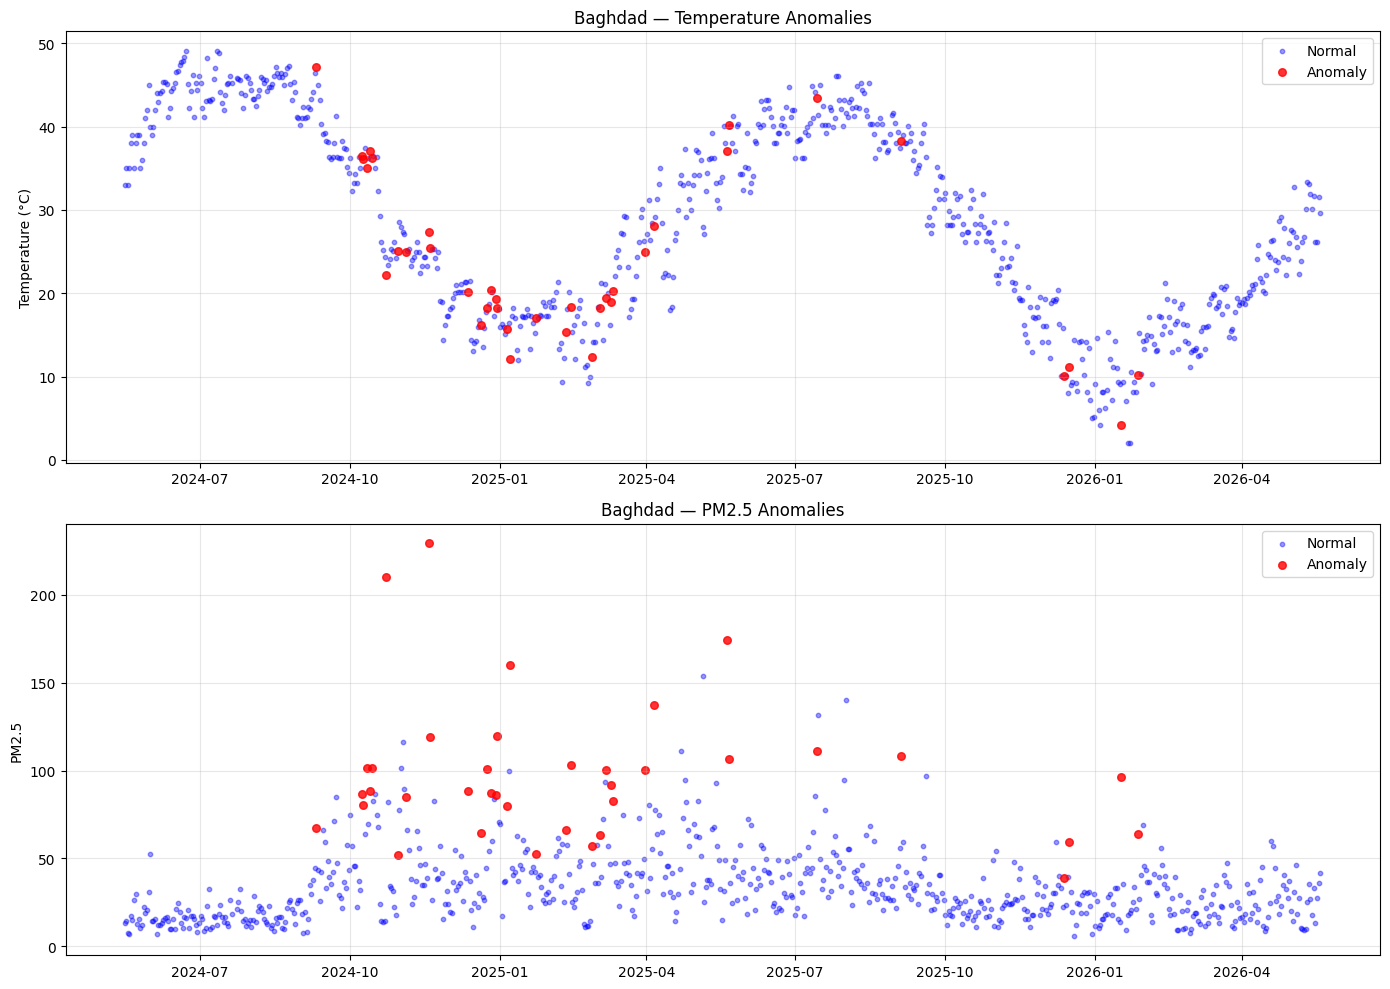


Anomaly Detection for Bern...
Total anomalies detected: 37 out of 732 days
Anomaly rate: 5.05%

Top 5 most anomalous periods:
                     temperature_celsius  humidity  air_quality_PM2.5
readable_date                                                        
2024-08-13 12:45:00                 30.8        38              8.100
2024-09-01 12:00:00                 28.2        51              8.900
2024-10-30 09:00:00                 13.8        78             43.105
2024-10-31 09:00:00                 12.6        77             12.580
2024-11-01 09:15:00                 13.4        67             12.395


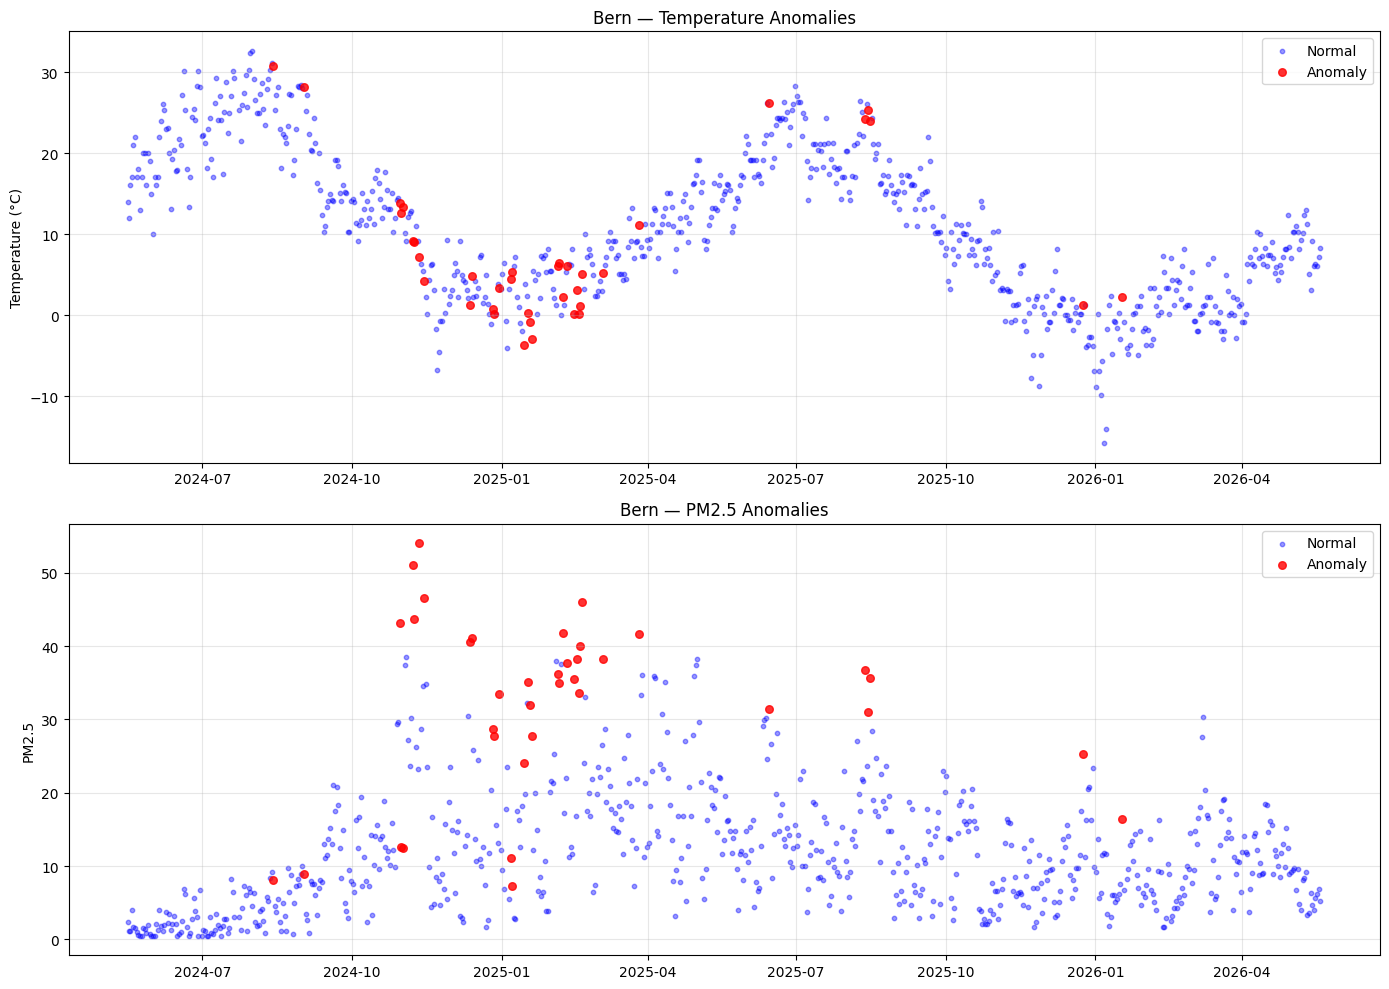


Anomaly Detection for Kyiv...
Total anomalies detected: 37 out of 732 days
Anomaly rate: 5.05%

Top 5 most anomalous periods:
                     temperature_celsius  humidity  air_quality_PM2.5
readable_date                                                        
2024-08-17 12:15:00                 32.7        19              9.000
2024-08-20 12:15:00                 35.8        15              9.900
2024-08-21 12:15:00                 35.7        11             19.300
2024-09-11 12:15:00                 28.1        30             35.335
2024-09-15 12:00:00                 28.7        16             37.185


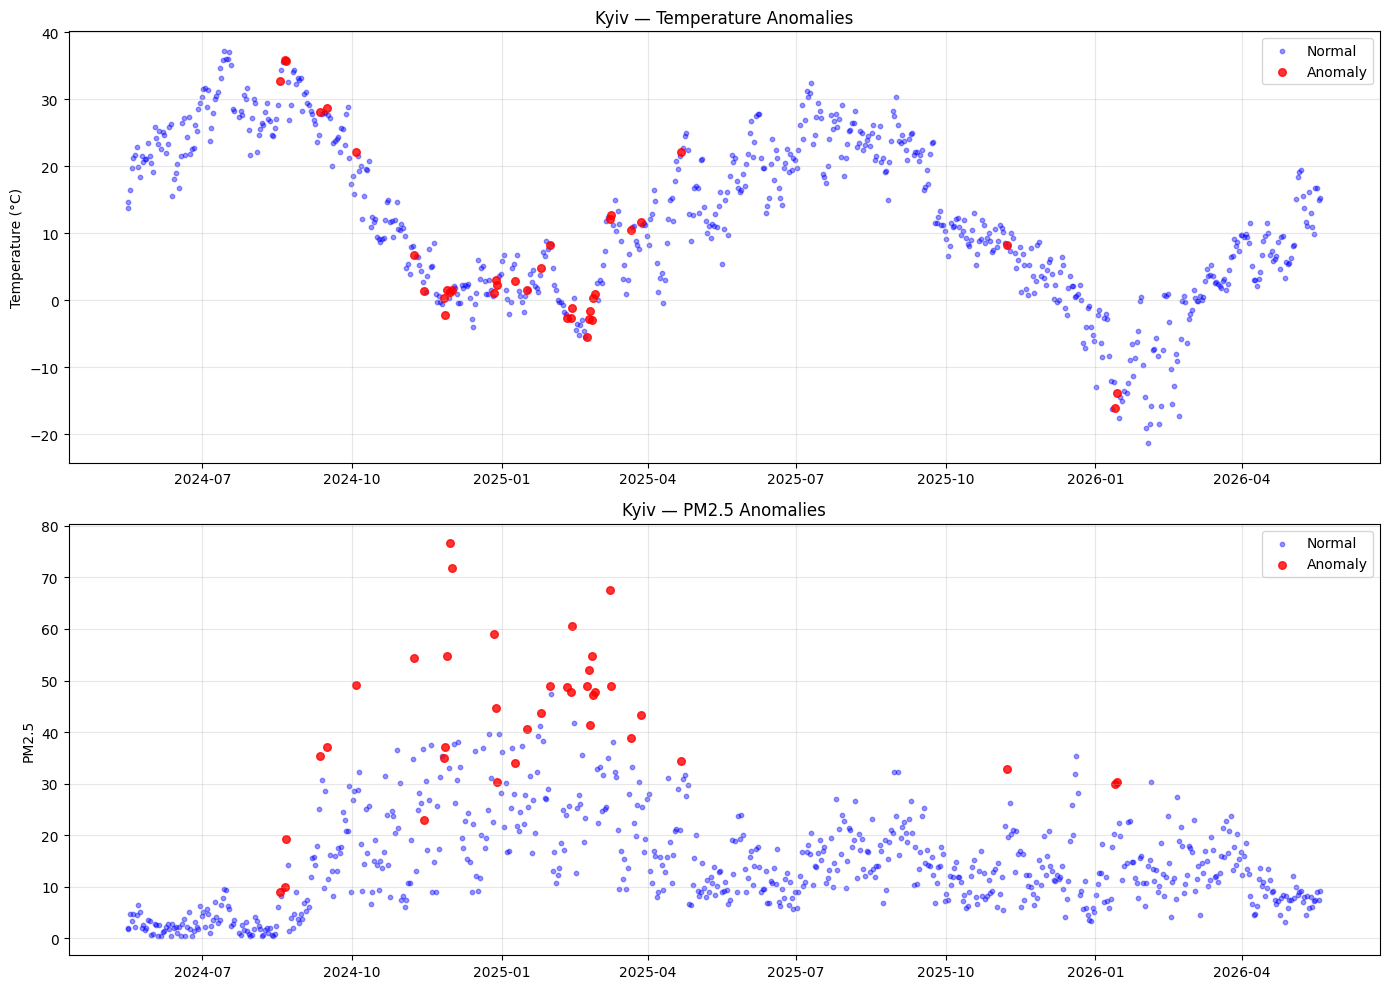

In [29]:
anomaly_results = {}

for city in cities:
    city_data, n_anomalies = run_isolation_forest(cleaned, city, features)
    plot_anomalies(city_data, city)
    anomaly_results[city] = {
        'data': city_data,
        'n_anomalies': n_anomalies
    }

In [30]:
for city in cities:
    city_data = anomaly_results[city]['data']
    anomalies = city_data[city_data['is_anomaly']]
    
    print(f"\n{city} — Anomalous Days Summary:")
    print(f"Average temperature on anomalous days: {anomalies['temperature_celsius'].mean():.2f}°C")
    print(f"Average temperature on normal days: {city_data[~city_data['is_anomaly']]['temperature_celsius'].mean():.2f}°C")
    print(f"Average PM2.5 on anomalous days: {anomalies['air_quality_PM2.5'].mean():.2f}")
    print(f"Average PM2.5 on normal days: {city_data[~city_data['is_anomaly']]['air_quality_PM2.5'].mean():.2f}")
    print(f"Average humidity on anomalous days: {anomalies['humidity'].mean():.2f}%")
    print(f"Average humidity on normal days: {city_data[~city_data['is_anomaly']]['humidity'].mean():.2f}%")


N'djamena — Anomalous Days Summary:
Average temperature on anomalous days: 29.06°C
Average temperature on normal days: 29.32°C
Average PM2.5 on anomalous days: 89.41
Average PM2.5 on normal days: 44.84
Average humidity on anomalous days: 48.97%
Average humidity on normal days: 39.52%

Baghdad — Anomalous Days Summary:
Average temperature on anomalous days: 23.81°C
Average temperature on normal days: 28.72°C
Average PM2.5 on anomalous days: 97.86
Average PM2.5 on normal days: 33.17
Average humidity on anomalous days: 38.41%
Average humidity on normal days: 30.50%

Bern — Anomalous Days Summary:
Average temperature on anomalous days: 7.86°C
Average temperature on normal days: 10.94°C
Average PM2.5 on anomalous days: 32.17
Average PM2.5 on normal days: 11.52
Average humidity on anomalous days: 73.19%
Average humidity on normal days: 78.72%

Kyiv — Anomalous Days Summary:
Average temperature on anomalous days: 6.68°C
Average temperature on normal days: 12.25°C
Average PM2.5 on anomalous d

1. PM2.5 is the primary driver: Massive spikes in PM2.5 are the leading cause of anomalous air quality days across all four cities.

2. Temperature is unreliable: Anomalous days aren't always hotter; temperatures are frequently normal or even lower during spikes.

3. Non-thermal causes dominate: Extreme pollution is driven by factors beyond heat, such as dust storms, industrial events, or seasonal agricultural burning.

4. Clean cities aren't immune: Even historically low-burden cities like Bern experience dramatic relative spikes in PM2.5 on anomalous days.

In [31]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:06
   ---------------------------------------- 0.8/101.7 MB 1.4 MB/s eta 0:01:11
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 1.3/101.7 MB 1.1 MB/s eta 0:01:31
    --------------------------------------- 1.6/101.7 MB 1.1 MB/s eta 0:01:30
    --------------------------------------- 1.6/101.7 MB 1.1 MB/s eta 0:01:30
    --------------------------------------- 1.8/101.7 MB 998.0 kB/s eta 0:01:41
    --------------------------------------- 1.8/101.7 MB 998.0 kB/s eta 0:01:41
    --------------------------------------- 2.1/101.7 MB 1.0 MB/s eta 0:01:39
   


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


FEATURE IMPORTANCE

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

importance_features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

target = 'air_quality_us-epa-index'

def run_xgboost_importance(cleaned, city_name, features, target):
    print(f"\nXGBoost Feature Importance for {city_name}")
    
    
    city_data = cleaned[cleaned['location_name'] == city_name][
        features + [target]
    ].copy().dropna()
    
    X = city_data[features]
    y = city_data[target].astype(float)
    
   
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    
   
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 5 most important features:")
    print(importance_df.head())
    
    return model, importance_df

def plot_importance(importance_df, city_name):
    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df['feature'][::-1],
        importance_df['importance'][::-1],
        color='steelblue',
        edgecolor='black',
        alpha=0.8
    )
    plt.xlabel('Feature Importance Score')
    plt.title(f'{city_name} — XGBoost Feature Importance for AQI Prediction')
    plt.tight_layout()
    plt.show()


XGBoost Feature Importance for N'djamena
MAE:  0.0163
RMSE: 0.1199

Top 5 most important features:
                        feature  importance
12            air_quality_PM2.5    0.988601
6                 visibility_km    0.006156
8   air_quality_Carbon_Monoxide    0.001505
13             air_quality_PM10    0.001289
0           temperature_celsius    0.000697


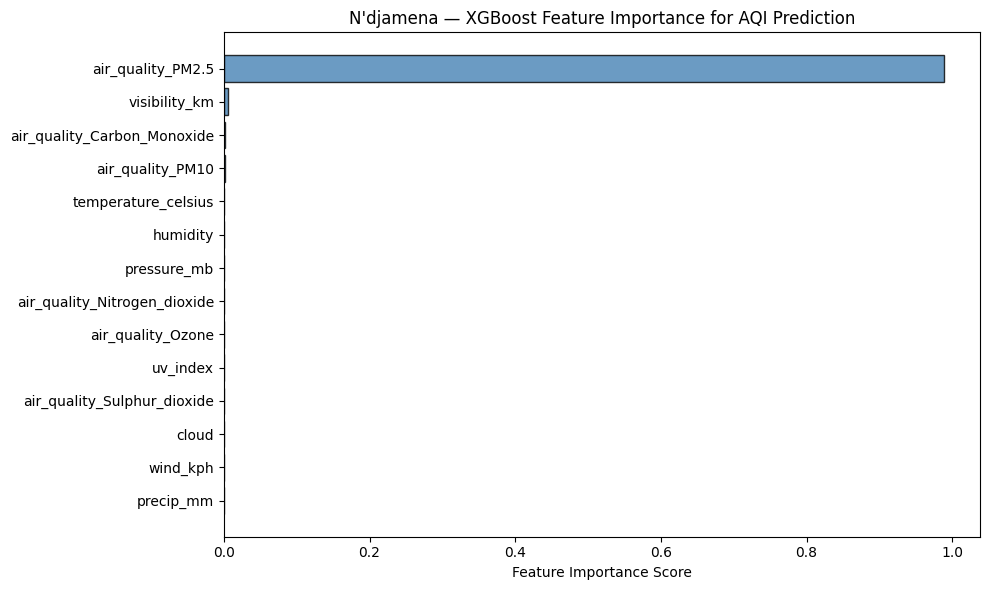


XGBoost Feature Importance for Baghdad
MAE:  0.0277
RMSE: 0.1021

Top 5 most important features:
                        feature  importance
12            air_quality_PM2.5    0.990507
0           temperature_celsius    0.003264
13             air_quality_PM10    0.002706
2                   pressure_mb    0.000794
8   air_quality_Carbon_Monoxide    0.000646


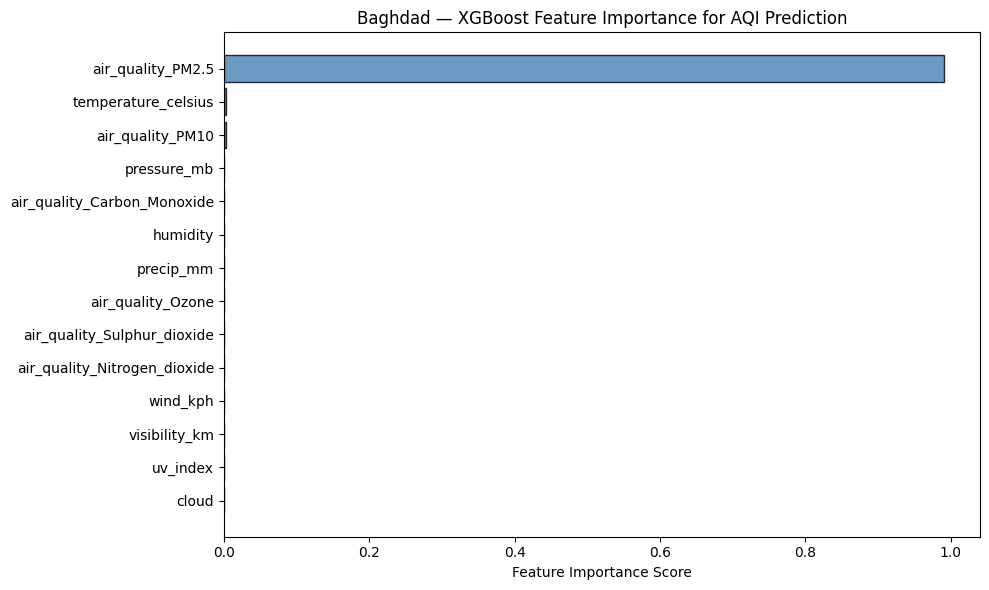


XGBoost Feature Importance for Bern
MAE:  0.0000
RMSE: 0.0000

Top 5 most important features:
                feature  importance
12    air_quality_PM2.5         1.0
0   temperature_celsius         0.0
2           pressure_mb         0.0
3              wind_kph         0.0
4             precip_mm         0.0


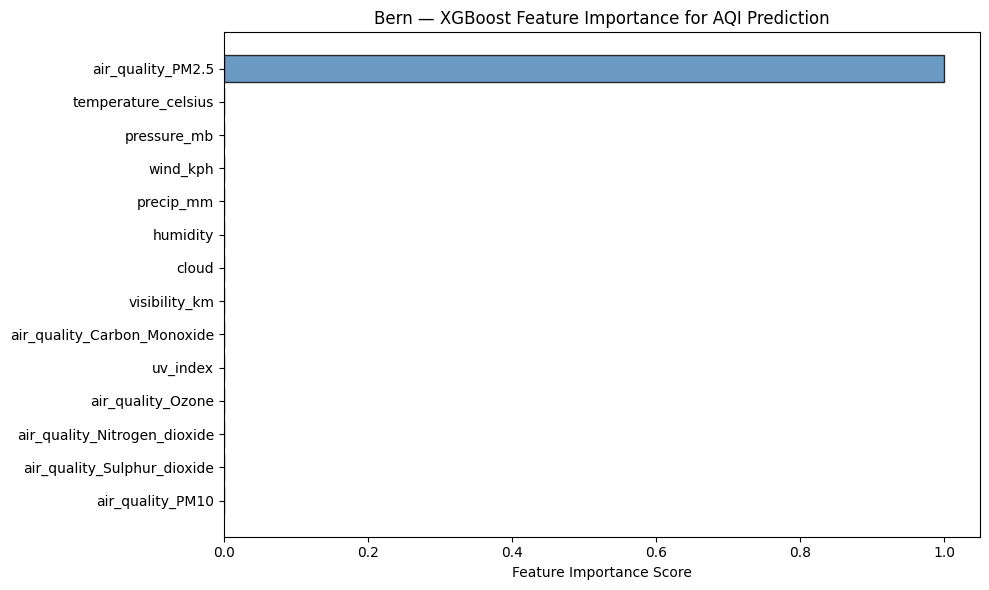


XGBoost Feature Importance for Kyiv
MAE:  0.0067
RMSE: 0.0807

Top 5 most important features:
                         feature  importance
12             air_quality_PM2.5    0.930704
10  air_quality_Nitrogen_dioxide    0.022258
8    air_quality_Carbon_Monoxide    0.015881
0            temperature_celsius    0.015617
13              air_quality_PM10    0.008380


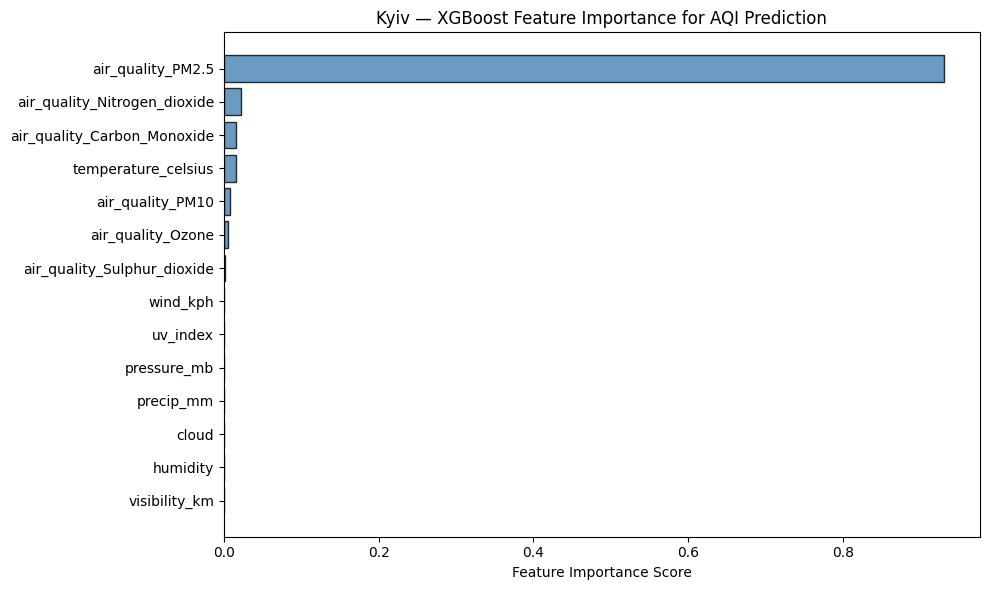

In [33]:
results = {}

for city in cities:
    model, importance_df = run_xgboost_importance(
        cleaned, city, importance_features, target
    )
    plot_importance(importance_df, city)
    results[city] = {
        'model': model,
        'importance': importance_df
    }

Weather patterns alone cannot reliably forecast dangerous air quality because AQI is overwhelmingly determined by PM2.5 particle pollution, which spikes independently of temperature and seasonal weather cycles. Early warning systems for health risk must prioritize PM2.5 monitoring over general weather forecasting.

However, Bern's perfect XGBoost score suggests the EPA index is deterministically driven by PM2.5 in this city, limiting the analytical value of feature importance here.

In [ ]:
col_removed = [
    'temperature_fahrenheit',
    'wind_mph',
    'precip_in',
    'pressure_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph'
]

existing_cols = [col for col in col_removed if col in d.columns]
map_df = d.drop(columns=existing_cols)

print(f"Map dataframe cities: {map_df['location_name'].nunique()}")
print(f"Map dataframe shape: {map_df.shape}")

Map dataframe cities: 257
Map dataframe shape: (142288, 35)


In [36]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


GEOGRAPHICAL PATTERNS

In [37]:
import plotly.express as px
import plotly.graph_objects as go


def prepare_map_data(cleaned):
    map_data = cleaned.groupby(['location_name', 'country']).agg(
        latitude=('latitude', 'mean'),
        longitude=('longitude', 'mean'),
        avg_temperature=('temperature_celsius', 'mean'),
        avg_aqi=('air_quality_us-epa-index', 'mean'),
        avg_pm25=('air_quality_PM2.5', 'mean'),
        avg_humidity=('humidity', 'mean')
    ).reset_index()
    
    
    map_data['temp_normalized'] = (
        map_data['avg_temperature'] - map_data['avg_temperature'].min()
    ) / (map_data['avg_temperature'].max() - map_data['avg_temperature'].min())
    
    map_data['aqi_normalized'] = (
        map_data['avg_aqi'] - map_data['avg_aqi'].min()
    ) / (map_data['avg_aqi'].max() - map_data['avg_aqi'].min())
    
    map_data['combined_burden'] = (
        map_data['temp_normalized'] + map_data['aqi_normalized']
    ) / 2
    
    return map_data

def plot_world_map(map_data):
    fig = px.scatter_geo(
        map_data,
        lat='latitude',
        lon='longitude',
        color='combined_burden',
        size='avg_pm25',
        hover_name='location_name',
        hover_data={
            'country': True,
            'avg_temperature': ':.2f',
            'avg_aqi': ':.2f',
            'avg_pm25': ':.2f',
            'combined_burden': ':.3f',
            'latitude': False,
            'longitude': False
        },
        color_continuous_scale='RdYlBu_r',
        size_max=20,
        title='Global Health Risk Burden: Combined Heat and Air Quality Index',
        labels={
            'combined_burden': 'Combined Burden Score',
            'avg_pm25': 'Avg PM2.5',
            'avg_temperature': 'Avg Temp (°C)',
            'avg_aqi': 'Avg AQI'
        }
    )
    
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth',
            showland=True,
            landcolor='lightgray',
            showocean=True,
            oceancolor='lightblue',
            showcountries=True,
            countrycolor='white'
        ),
        coloraxis_colorbar=dict(
            title='Combined<br>Burden Score',
            thickness=15,
            len=0.7
        ),
        title_font_size=16,
        height=600
    )
    
    fig.show()
    
    fig.write_html('global_health_burden_map.html')
    print("Map saved as global_health_burden_map.html")
    
    return fig

In [38]:
map_data = prepare_map_data(map_df)

print(f"Cities on map: {len(map_data)}")
print(f"\nTop 10 highest burden cities:")
print(map_data.nlargest(10, 'combined_burden')[
    ['location_name', 'country', 'avg_temperature', 'avg_aqi', 'combined_burden']
].to_string())

print(f"\nTop 10 lowest burden cities:")
print(map_data.nsmallest(10, 'combined_burden')[
    ['location_name', 'country', 'avg_temperature', 'avg_aqi', 'combined_burden']
].to_string())

fig = plot_world_map(map_data)

Cities on map: 270

Top 10 highest burden cities:
        location_name       country  avg_temperature   avg_aqi  combined_burden
118            Kuwait        Kuwait        44.400000  5.000000         0.994782
102           Jakarta     Indonesia        30.210807  4.136799         0.763476
208            Riyadh  Saudi Arabia        30.459041  3.928767         0.739631
167         New Delhi         India        29.963786  3.916324         0.733769
97   Ho Chi Minh City       Vietnam        26.600000  4.000000         0.714973
229             Seoul      Südkorea        26.100000  4.000000         0.710624
119       Kuwait City        Kuwait        30.674760  3.644719         0.706001
38            Beijing         China        17.984066  4.054945         0.646907
139            Manama       Bahrain        29.618468  3.173735         0.637942
93              Hanoi       Vietnam        27.293699  3.330137         0.637273

Top 10 lowest burden cities:
         location_name                  

Map saved as global_health_burden_map.html


** 270 location entries identified across 257 countries, with minor duplicates likely reflecting data collection overlap — e.g. Kuwait and Kuwait City appearing separately.

Among cities with complete time series data, N'djamena and Baghdad showed the highest burden scores. However global spatial analysis across all 257 cities reveals Middle Eastern capitals — particularly Kuwait and Riyadh — and South Asian megacities — particularly New Delhi and Jakarta — carry the highest combined heat and pollution burden worldwide.

GEOGRAPHICAL PATTERNS

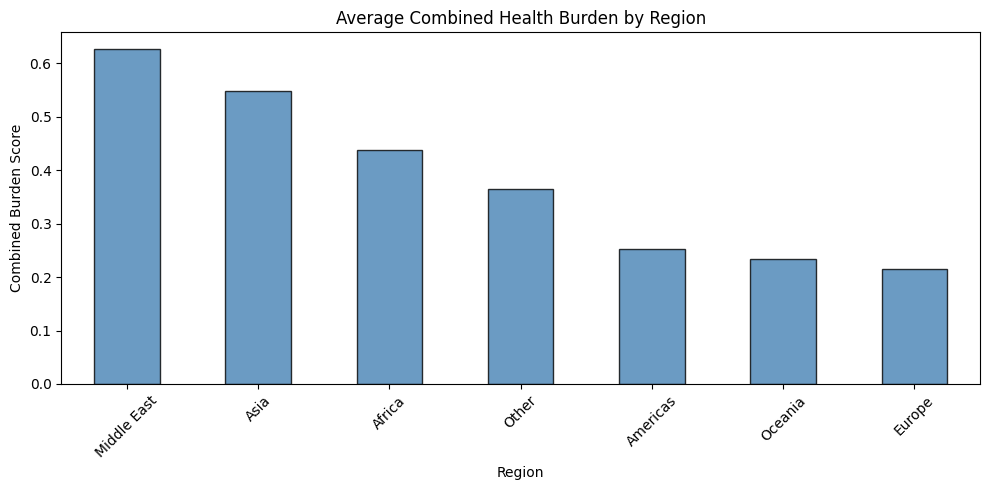

region
Middle East    0.626522
Asia           0.547677
Africa         0.437603
Other          0.365197
Americas       0.253284
Oceania        0.233238
Europe         0.214506
Name: combined_burden, dtype: float64


In [39]:

region_map = {
    'Asia': ['China', 'Japan', 'India', 'Indonesia', 'Vietnam', 
             'Thailand', 'South Korea', 'Südkorea'],
    'Middle East': ['Kuwait', 'Saudi Arabia', 'Bahrain', 'Iraq', 
                    'Jordan', 'Yemen'],
    'Europe': ['Switzerland', 'Finland', 'Andorra', 'Iceland', 
               'France', 'Germany', 'Poland', 'Ukraine'],
    'Africa': ['Chad', 'Senegal', 'Ghana', 'Burundi', 
               'Eritrea', 'Equatorial Guinea'],
    'Americas': ['Canada', 'United States of America', 
                 'Argentina', 'Brazil'],
    'Oceania': ['Fiji', 'Australia']
}

def assign_region(country):
    for region, countries in region_map.items():
        if country in countries:
            return region
    return 'Other'

map_data['region'] = map_data['country'].apply(assign_region)

regional_summary = map_data.groupby('region')['combined_burden'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
regional_summary.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Average Combined Health Burden by Region')
plt.ylabel('Combined Burden Score')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(regional_summary)